In [86]:
#Import all relevant libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore
 
## This statement allows the visuals to render within your Jupyter Notebook.
%matplotlib inline

## Loading the data
We can now load the dataset into pandas using the read_csv() function. This converts the CSV file into a Pandas dataframe.

In [87]:
#Read in the csv file and convert to a Pandas dataframe
h15_df = pd.read_csv('./data/2015.csv')
h16_df = pd.read_csv('./data/2016.csv')
h17_df = pd.read_csv('./data/2017.csv')
h18_df = pd.read_csv('./data/2018.csv')
h19_df = pd.read_csv('./data/2019.csv')

### Viewing the dataframe
We can get a quick sense of the size of our dataset by using the shape method. This returns a tuple with the number of rows and columns in the dataset.

In [88]:
h15_df.shape, h16_df.shape, h17_df.shape, h18_df.shape, h19_df.shape

((158, 12), (157, 13), (155, 12), (156, 9), (156, 9))

## 1. Data Profiling:
Data profiling is a comprehensive process of examining the data available in an existing dataset and collecting statistics and information about that data. 

In [89]:
h15_df.info(), h16_df.info(), h17_df.info(), h18_df.info(), h19_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 158 entries, 0 to 157
Data columns (total 12 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Country                        158 non-null    object 
 1   Region                         158 non-null    object 
 2   Happiness Rank                 158 non-null    int64  
 3   Happiness Score                158 non-null    float64
 4   Standard Error                 158 non-null    float64
 5   Economy (GDP per Capita)       158 non-null    float64
 6   Family                         158 non-null    float64
 7   Health (Life Expectancy)       158 non-null    float64
 8   Freedom                        158 non-null    float64
 9   Trust (Government Corruption)  158 non-null    float64
 10  Generosity                     158 non-null    float64
 11  Dystopia Residual              158 non-null    float64
dtypes: float64(9), int64(1), object(2)
memory usage: 1

(None, None, None, None, None)

In [90]:
h15_df.describe(include='all')

,Country,Region,Happiness Rank,Happiness Score,Standard Error,Economy (GDP per Capita),Family,Health (Life Expectancy),Freedom,Trust (Government Corruption),Generosity,Dystopia Residual
count,158,158,158.000000,158.000000,158.000000,158.000000,158.000000,158.000000,158.000000,158.000000,158.000000,158.000000
unique,158,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,Switzerland,Sub-Saharan Africa,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,40,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,79.493671,5.375734,0.047885,0.846137,0.991046,0.630259,0.428615,0.143422,0.237296,2.098977
std,NaN,NaN,45.754363,1.145010,0.017146,0.403121,0.272369,0.247078,0.150693,0.120034,0.126685,0.553550
min,NaN,NaN,1.000000,2.839000,0.018480,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.328580
25%,NaN,NaN,40.250000,4.526000,0.037268,0.545808,0.856823,0.439185,0.328330,0.061675,0.150553,1.759410
50%,NaN,NaN,79.500000,5.232500,0.043940,0.910245,1.029510,0.696705,0.435515,0.107220,0.216130,2.095415
75%,NaN,NaN,118.750000,6.243750,0.052300,1.158448,1.214405,0.811013,0.549092,0.180255,0.309883,2.462415


In [91]:
h16_df.describe(include='all')

,Country,Region,Happiness Rank,Happiness Score,Lower Confidence Interval,Upper Confidence Interval,Economy (GDP per Capita),Family,Health (Life Expectancy),Freedom,Trust (Government Corruption),Generosity,Dystopia Residual
count,157,157,157.000000,157.000000,157.000000,157.000000,157.000000,157.000000,157.000000,157.000000,157.000000,157.000000,157.000000
unique,157,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,Denmark,Sub-Saharan Africa,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,38,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,78.980892,5.382185,5.282395,5.481975,0.953880,0.793621,0.557619,0.370994,0.137624,0.242635,2.325807
std,NaN,NaN,45.466030,1.141674,1.148043,1.136493,0.412595,0.266706,0.229349,0.145507,0.111038,0.133756,0.542220
min,NaN,NaN,1.000000,2.905000,2.732000,3.078000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.817890
25%,NaN,NaN,40.000000,4.404000,4.327000,4.465000,0.670240,0.641840,0.382910,0.257480,0.061260,0.154570,2.031710
50%,NaN,NaN,79.000000,5.314000,5.237000,5.419000,1.027800,0.841420,0.596590,0.397470,0.105470,0.222450,2.290740
75%,NaN,NaN,118.000000,6.269000,6.154000,6.434000,1.279640,1.021520,0.729930,0.484530,0.175540,0.311850,2.664650


In [92]:
h17_df.describe(include='all')

,Country,Happiness.Rank,Happiness.Score,Whisker.high,Whisker.low,Economy..GDP.per.Capita.,Family,Health..Life.Expectancy.,Freedom,Generosity,Trust..Government.Corruption.,Dystopia.Residual
count,155,155.000000,155.000000,155.000000,155.000000,155.000000,155.000000,155.000000,155.000000,155.000000,155.000000,155.000000
unique,155,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,Norway,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,78.000000,5.354019,5.452326,5.255713,0.984718,1.188898,0.551341,0.408786,0.246883,0.123120,1.850238
std,NaN,44.888751,1.131230,1.118542,1.145030,0.420793,0.287263,0.237073,0.149997,0.134780,0.101661,0.500028
min,NaN,1.000000,2.693000,2.864884,2.521116,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.377914
25%,NaN,39.500000,4.505500,4.608172,4.374955,0.663371,1.042635,0.369866,0.303677,0.154106,0.057271,1.591291
50%,NaN,78.000000,5.279000,5.370032,5.193152,1.064578,1.253918,0.606042,0.437454,0.231538,0.089848,1.832910
75%,NaN,116.500000,6.101500,6.194600,6.006527,1.318027,1.414316,0.723008,0.516561,0.323762,0.153296,2.144654


In [93]:
h18_df.describe(include='all')

,Overall rank,Country or region,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
count,156.000000,156,156.000000,156.000000,156.000000,156.000000,156.000000,156.000000,155.000000
unique,NaN,156,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,Finland,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,78.500000,NaN,5.375917,0.891449,1.213237,0.597346,0.454506,0.181006,0.112000
std,45.177428,NaN,1.119506,0.391921,0.302372,0.247579,0.162424,0.098471,0.096492
min,1.000000,NaN,2.905000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,39.750000,NaN,4.453750,0.616250,1.066750,0.422250,0.356000,0.109500,0.051000
50%,78.500000,NaN,5.378000,0.949500,1.255000,0.644000,0.487000,0.174000,0.082000
75%,117.250000,NaN,6.168500,1.197750,1.463000,0.777250,0.578500,0.239000,0.137000


In [94]:
h19_df.describe(include='all')

,Overall rank,Country or region,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
count,156.000000,156,156.000000,156.000000,156.000000,156.000000,156.000000,156.000000,156.000000
unique,NaN,156,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,Finland,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,78.500000,NaN,5.407096,0.905147,1.208814,0.725244,0.392571,0.184846,0.110603
std,45.177428,NaN,1.113120,0.398389,0.299191,0.242124,0.143289,0.095254,0.094538
min,1.000000,NaN,2.853000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,39.750000,NaN,4.544500,0.602750,1.055750,0.547750,0.308000,0.108750,0.047000
50%,78.500000,NaN,5.379500,0.960000,1.271500,0.789000,0.417000,0.177500,0.085500
75%,117.250000,NaN,6.184500,1.232500,1.452500,0.881750,0.507250,0.248250,0.141250


The process of profiling differs slightly for categorical and numerical variables due to their inherent differences.

**The two main types of data are:**
- Quantitative (numerical) data
- Qualitative (categorical) data

### Data Quality Checks
Data quality checks involve the process of ensuring that the data is accurate, complete, consistent, relevant, and reliable. 


**Here are typical steps involved in checking data quality:**

#### 1. Reliability:
Evaluate the data's source and collection process to determine its trustworthiness.

In [95]:
""" 
Data source mentioned in kaggle page
 The World Happiness Report is a landmark survey of the state of global happiness.
 URL: https://worldhappiness.report/data/ 
"""

' \nData source mentioned in kaggle page\n The World Happiness Report is a landmark survey of the state of global happiness.\n URL: https://worldhappiness.report/data/ \n'

#### 2. Timeliness: 
Ensure the data is up-to-date and reflective of the current situation or the period of interest for the analysis.

In [96]:
"""
We have data from 2015-2019. Therefore, it isn't up-to-date, 
so we will go back & check if there is any new data available for 2020 and above.

After checking the data source, we found that the data is available for 2024.

So we will download the data.

"""

h24_df = pd.read_csv('./data/2024.csv')

#### 3. Consistency: 

Confirm that the data is consistent within the dataset and across multiple data sources. For example, the same data point should not have different values in different places.


In [97]:
h16_df.head()

,Country,Region,Happiness Rank,Happiness Score,Lower Confidence Interval,Upper Confidence Interval,Economy (GDP per Capita),Family,Health (Life Expectancy),Freedom,Trust (Government Corruption),Generosity,Dystopia Residual
0,Denmark,Western Europe,1,7.526,7.460,7.592,1.44178,1.16374,0.79504,0.57941,0.44453,0.36171,2.73939
1,Switzerland,Western Europe,2,7.509,7.428,7.590,1.52733,1.14524,0.86303,0.58557,0.41203,0.28083,2.69463
2,Iceland,Western Europe,3,7.501,7.333,7.669,1.42666,1.18326,0.86733,0.56624,0.14975,0.47678,2.83137
3,Norway,Western Europe,4,7.498,7.421,7.575,1.57744,1.12690,0.79579,0.59609,0.35776,0.37895,2.66465
4,Finland,Western Europe,5,7.413,7.351,7.475,1.40598,1.13464,0.81091,0.57104,0.41004,0.25492,2.82596


In [98]:
h18_df.head()

,Overall rank,Country or region,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
0,1,Finland,7.632,1.305,1.592,0.874,0.681,0.202,0.393
1,2,Norway,7.594,1.456,1.582,0.861,0.686,0.286,0.340
2,3,Denmark,7.555,1.351,1.590,0.868,0.683,0.284,0.408
3,4,Iceland,7.495,1.343,1.644,0.914,0.677,0.353,0.138
4,5,Switzerland,7.487,1.420,1.549,0.927,0.660,0.256,0.357


In [99]:
"""
We have data from 2015-2019 & 2024, as shown above columns names are different.
But columns data type & logic is the same.
Therefore, data is consistent.
"""

'\nWe have data from 2015-2019 & 2024, as shown above columns names are different.\nBut columns data type & logic is the same.\nTherefore, data is consistent.\n'

#### 4. Relevance: 
Assess whether the data is appropriate and applicable for the intended analysis. Data that is not relevant can skew results and lead to incorrect conclusions.

**Key considerations for relevance include:**

> 1. Sample Appropriateness: Confirm that your data sample aligns with your analysis objectives. For instance, utilizing data from the Northern region will not yield accurate insights for the Western region of the Kingdom.
>
> 2. Variable Selection: Any column will not be relevant for our analysis, we can get rid of these using the drop() method. We will set the “axis” argument to 1 since we’re dealing with columns, and set the “inplace” argument to True to make the change permanent.


In [100]:
h16_df.sample(5)


,Country,Region,Happiness Rank,Happiness Score,Lower Confidence Interval,Upper Confidence Interval,Economy (GDP per Capita),Family,Health (Life Expectancy),Freedom,Trust (Government Corruption),Generosity,Dystopia Residual
66,Libya,Middle East and Northern Africa,67,5.615,5.406,5.824,1.06688,0.95076,0.52304,0.40672,0.10339,0.17087,2.39374
62,Slovenia,Central and Eastern Europe,63,5.768,5.683,5.853,1.29947,1.05613,0.79151,0.53164,0.03635,0.25738,1.79522
125,Georgia,Central and Eastern Europe,126,4.252,4.164,4.340,0.83792,0.19249,0.64035,0.32461,0.31880,0.06786,1.87031
153,Afghanistan,Southern Asia,154,3.360,3.288,3.432,0.38227,0.11037,0.17344,0.16430,0.07112,0.31268,2.14558
55,Russia,Central and Eastern Europe,56,5.856,5.789,5.923,1.23228,1.05261,0.58991,0.32682,0.03586,0.02736,2.59115


In [101]:
h17_df.sample(5)

,Country,Happiness.Rank,Happiness.Score,Whisker.high,Whisker.low,Economy..GDP.per.Capita.,Family,Health..Life.Expectancy.,Freedom,Generosity,Trust..Government.Corruption.,Dystopia.Residual
81,Venezuela,82,5.250,5.370032,5.129968,1.128431,1.431338,0.617144,0.153997,0.065020,0.064491,1.789464
84,Azerbaijan,85,5.234,5.299287,5.168714,1.153602,1.152400,0.540776,0.398156,0.045269,0.180988,1.762482
18,United Kingdom,19,6.714,6.783792,6.644209,1.441634,1.496460,0.805336,0.508190,0.492774,0.265428,1.704144
6,Canada,7,7.316,7.384403,7.247597,1.479204,1.481349,0.834558,0.611101,0.435540,0.287372,2.187264
131,Ukraine,132,4.096,4.185410,4.006590,0.894652,1.394538,0.575904,0.122975,0.270061,0.023029,0.814382


In [102]:
h15_df['Region'].value_counts()

Region
Sub-Saharan Africa                 40
Central and Eastern Europe         29
Latin America and Caribbean        22
Western Europe                     21
Middle East and Northern Africa    20
Southeastern Asia                   9
Southern Asia                       7
Eastern Asia                        6
North America                       2
Australia and New Zealand           2
Name: count, dtype: int64

#### 5. Uniqueness: 
Check for and remove duplicate records to prevent skewed analysis results.


In [103]:
h15_df.duplicated().value_counts()

False    158
Name: count, dtype: int64

In [104]:
h15_df.duplicated().value_counts()

False    158
Name: count, dtype: int64

In [105]:
h15_df.duplicated().value_counts()

False    158
Name: count, dtype: int64

In [106]:
h15_df.duplicated().value_counts()

False    158
Name: count, dtype: int64

In [107]:
h15_df.duplicated().value_counts()

False    158
Name: count, dtype: int64

In [108]:
h24_df.duplicated().value_counts()

False    143
Name: count, dtype: int64

In [109]:
h24_df.shape

(143, 11)

In [110]:
h24_df.duplicated().value_counts()

False    143
Name: count, dtype: int64

In [111]:
"""
No duplicate rows found in 2015-2019 & 2024, any of the dataframes.
"""

'\nNo duplicate rows found in 2015-2019 & 2024, any of the dataframes.\n'

#### 6. Completeness: 
Ensure that no critical data is missing. This might mean checking for null values or required fields that are empty.

We will start by checking the dataset for missing or null values. For this, we can use the isna() method which returns a dataframe of boolean values indicating if a field is null or not. To group all missing values by column, we can include the sum() method.

In [112]:
#Display number missing values per column
h15_df.isna().sum()

Country                          0
Region                           0
Happiness Rank                   0
Happiness Score                  0
Standard Error                   0
Economy (GDP per Capita)         0
Family                           0
Health (Life Expectancy)         0
Freedom                          0
Trust (Government Corruption)    0
Generosity                       0
Dystopia Residual                0
dtype: int64

In [113]:
h16_df.isna().sum()

Country                          0
Region                           0
Happiness Rank                   0
Happiness Score                  0
Lower Confidence Interval        0
Upper Confidence Interval        0
Economy (GDP per Capita)         0
Family                           0
Health (Life Expectancy)         0
Freedom                          0
Trust (Government Corruption)    0
Generosity                       0
Dystopia Residual                0
dtype: int64

In [114]:
h17_df.isna().sum()

Country                          0
Happiness.Rank                   0
Happiness.Score                  0
Whisker.high                     0
Whisker.low                      0
Economy..GDP.per.Capita.         0
Family                           0
Health..Life.Expectancy.         0
Freedom                          0
Generosity                       0
Trust..Government.Corruption.    0
Dystopia.Residual                0
dtype: int64

In [115]:
h18_df.isna().sum()

Overall rank                    0
Country or region               0
Score                           0
GDP per capita                  0
Social support                  0
Healthy life expectancy         0
Freedom to make life choices    0
Generosity                      0
Perceptions of corruption       1
dtype: int64

In [116]:
h18_df.shape

(156, 9)

In [117]:
h18_df = h18_df.dropna()

In [118]:
h18_df.shape

(155, 9)

In [119]:
h18_df.isna().sum()

Overall rank                    0
Country or region               0
Score                           0
GDP per capita                  0
Social support                  0
Healthy life expectancy         0
Freedom to make life choices    0
Generosity                      0
Perceptions of corruption       0
dtype: int64

In [120]:
h19_df.isna().sum()

Overall rank                    0
Country or region               0
Score                           0
GDP per capita                  0
Social support                  0
Healthy life expectancy         0
Freedom to make life choices    0
Generosity                      0
Perceptions of corruption       0
dtype: int64

In [121]:
h24_df.isna().sum()

Country name                                  0
Ladder score                                  0
upperwhisker                                  0
lowerwhisker                                  0
Explained by: Log GDP per capita              3
Explained by: Social support                  3
Explained by: Healthy life expectancy         3
Explained by: Freedom to make life choices    3
Explained by: Generosity                      3
Explained by: Perceptions of corruption       3
Dystopia + residual                           3
dtype: int64

In [122]:
h24_df.shape

(143, 11)

In [123]:
h24_df = h24_df.dropna()

In [124]:
h24_df.shape

(140, 11)

In [125]:
"""
2018 & 2024 data has missing values, so we dropped the rows with missing values.
So, we have cleaned the data.
"""

'\n2018 & 2024 data has missing values, so we dropped the rows with missing values.\nSo, we have cleaned the data.\n'

#### 7. Check Accuracy:

Verify that the data is correct and precise. This could involve comparing data samples with known sources or using validation rules.

**The process includes:**
1. Validating the appropriateness of data types for the dataset.
2. Identifying outliers  using established validation  rule

In [126]:
# check columns types 
h15_df.dtypes

Country                           object
Region                            object
Happiness Rank                     int64
Happiness Score                  float64
Standard Error                   float64
Economy (GDP per Capita)         float64
Family                           float64
Health (Life Expectancy)         float64
Freedom                          float64
Trust (Government Corruption)    float64
Generosity                       float64
Dystopia Residual                float64
dtype: object

In [127]:
h15_df['Country'].value_counts(ascending=False)

Country
Switzerland    1
Iceland        1
Denmark        1
Norway         1
Canada         1
              ..
Rwanda         1
Benin          1
Syria          1
Burundi        1
Togo           1
Name: count, Length: 158, dtype: int64

In [128]:
h16_df.dtypes

Country                           object
Region                            object
Happiness Rank                     int64
Happiness Score                  float64
Lower Confidence Interval        float64
Upper Confidence Interval        float64
Economy (GDP per Capita)         float64
Family                           float64
Health (Life Expectancy)         float64
Freedom                          float64
Trust (Government Corruption)    float64
Generosity                       float64
Dystopia Residual                float64
dtype: object

In [129]:
h16_df['Country'].value_counts(ascending=False)

Country
Denmark        1
Switzerland    1
Iceland        1
Norway         1
Finland        1
              ..
Benin          1
Afghanistan    1
Togo           1
Syria          1
Burundi        1
Name: count, Length: 157, dtype: int64

In [130]:
h17_df.dtypes

Country                           object
Happiness.Rank                     int64
Happiness.Score                  float64
Whisker.high                     float64
Whisker.low                      float64
Economy..GDP.per.Capita.         float64
Family                           float64
Health..Life.Expectancy.         float64
Freedom                          float64
Generosity                       float64
Trust..Government.Corruption.    float64
Dystopia.Residual                float64
dtype: object

In [131]:
h17_df['Country'].value_counts(ascending=False)

Country
Norway                      1
Denmark                     1
Iceland                     1
Switzerland                 1
Finland                     1
                           ..
Rwanda                      1
Syria                       1
Tanzania                    1
Burundi                     1
Central African Republic    1
Name: count, Length: 155, dtype: int64

In [132]:
h18_df.dtypes

Overall rank                      int64
Country or region                object
Score                           float64
GDP per capita                  float64
Social support                  float64
Healthy life expectancy         float64
Freedom to make life choices    float64
Generosity                      float64
Perceptions of corruption       float64
dtype: object

In [133]:
h18_df['Country or region'].value_counts(ascending=False)

Country or region
Finland                     1
Norway                      1
Denmark                     1
Iceland                     1
Switzerland                 1
                           ..
Yemen                       1
Tanzania                    1
South Sudan                 1
Central African Republic    1
Burundi                     1
Name: count, Length: 155, dtype: int64

In [134]:
h19_df.dtypes

Overall rank                      int64
Country or region                object
Score                           float64
GDP per capita                  float64
Social support                  float64
Healthy life expectancy         float64
Freedom to make life choices    float64
Generosity                      float64
Perceptions of corruption       float64
dtype: object

In [135]:
h19_df['Country or region'].value_counts(ascending=False)

Country or region
Finland                     1
Denmark                     1
Norway                      1
Iceland                     1
Netherlands                 1
                           ..
Rwanda                      1
Tanzania                    1
Afghanistan                 1
Central African Republic    1
South Sudan                 1
Name: count, Length: 156, dtype: int64

In [136]:
h24_df.dtypes

Country name                                   object
Ladder score                                  float64
upperwhisker                                  float64
lowerwhisker                                  float64
Explained by: Log GDP per capita              float64
Explained by: Social support                  float64
Explained by: Healthy life expectancy         float64
Explained by: Freedom to make life choices    float64
Explained by: Generosity                      float64
Explained by: Perceptions of corruption       float64
Dystopia + residual                           float64
dtype: object

In [137]:
h24_df['Country name'].value_counts(ascending=False)

Country name
Finland             1
Denmark             1
Iceland             1
Sweden              1
Israel              1
                   ..
Congo (Kinshasa)    1
Sierra Leone        1
Lesotho             1
Lebanon             1
Afghanistan         1
Name: count, Length: 140, dtype: int64

In [138]:
# We will change the columns names to make it consistent across all dataframes

In [139]:
h15_df.describe()

,Happiness Rank,Happiness Score,Standard Error,Economy (GDP per Capita),Family,Health (Life Expectancy),Freedom,Trust (Government Corruption),Generosity,Dystopia Residual
count,158.000000,158.000000,158.000000,158.000000,158.000000,158.000000,158.000000,158.000000,158.000000,158.000000
mean,79.493671,5.375734,0.047885,0.846137,0.991046,0.630259,0.428615,0.143422,0.237296,2.098977
std,45.754363,1.145010,0.017146,0.403121,0.272369,0.247078,0.150693,0.120034,0.126685,0.553550
min,1.000000,2.839000,0.018480,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.328580
25%,40.250000,4.526000,0.037268,0.545808,0.856823,0.439185,0.328330,0.061675,0.150553,1.759410
50%,79.500000,5.232500,0.043940,0.910245,1.029510,0.696705,0.435515,0.107220,0.216130,2.095415
75%,118.750000,6.243750,0.052300,1.158448,1.214405,0.811013,0.549092,0.180255,0.309883,2.462415
max,158.000000,7.587000,0.136930,1.690420,1.402230,1.025250,0.669730,0.551910,0.795880,3.602140


In [140]:
h15_df.columns

Index(['Country', 'Region', 'Happiness Rank', 'Happiness Score',
       'Standard Error', 'Economy (GDP per Capita)', 'Family',
       'Health (Life Expectancy)', 'Freedom', 'Trust (Government Corruption)',
       'Generosity', 'Dystopia Residual'],
      dtype='object')

In [141]:
h15_df.columns = ['Country', 'Region' , 'Rank', 'Score', 'Standard Error', 'Economy (GDP per Capita)', 'Family', 'Health (Life Expectancy)', 'Freedom', 'Trust (Government Corruption)', 'Generosity', 'Dystopia Residual']

In [142]:
h15_df.columns

Index(['Country', 'Region', 'Rank', 'Score', 'Standard Error',
       'Economy (GDP per Capita)', 'Family', 'Health (Life Expectancy)',
       'Freedom', 'Trust (Government Corruption)', 'Generosity',
       'Dystopia Residual'],
      dtype='object')

In [143]:
h16_df.describe()

,Happiness Rank,Happiness Score,Lower Confidence Interval,Upper Confidence Interval,Economy (GDP per Capita),Family,Health (Life Expectancy),Freedom,Trust (Government Corruption),Generosity,Dystopia Residual
count,157.000000,157.000000,157.000000,157.000000,157.000000,157.000000,157.000000,157.000000,157.000000,157.000000,157.000000
mean,78.980892,5.382185,5.282395,5.481975,0.953880,0.793621,0.557619,0.370994,0.137624,0.242635,2.325807
std,45.466030,1.141674,1.148043,1.136493,0.412595,0.266706,0.229349,0.145507,0.111038,0.133756,0.542220
min,1.000000,2.905000,2.732000,3.078000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.817890
25%,40.000000,4.404000,4.327000,4.465000,0.670240,0.641840,0.382910,0.257480,0.061260,0.154570,2.031710
50%,79.000000,5.314000,5.237000,5.419000,1.027800,0.841420,0.596590,0.397470,0.105470,0.222450,2.290740
75%,118.000000,6.269000,6.154000,6.434000,1.279640,1.021520,0.729930,0.484530,0.175540,0.311850,2.664650
max,157.000000,7.526000,7.460000,7.669000,1.824270,1.183260,0.952770,0.608480,0.505210,0.819710,3.837720


In [144]:
h16_df.columns

Index(['Country', 'Region', 'Happiness Rank', 'Happiness Score',
       'Lower Confidence Interval', 'Upper Confidence Interval',
       'Economy (GDP per Capita)', 'Family', 'Health (Life Expectancy)',
       'Freedom', 'Trust (Government Corruption)', 'Generosity',
       'Dystopia Residual'],
      dtype='object')

In [145]:
h16_df.columns = ['Country', 'Region' , 'Rank', 'Score', 'Lower Confidence Interval', 'Upper Confidence Interval' ,'Economy (GDP per Capita)', 'Family', 'Health (Life Expectancy)', 'Freedom', 'Trust (Government Corruption)', 'Generosity', 'Dystopia Residual']

In [146]:
h17_df.describe()

,Happiness.Rank,Happiness.Score,Whisker.high,Whisker.low,Economy..GDP.per.Capita.,Family,Health..Life.Expectancy.,Freedom,Generosity,Trust..Government.Corruption.,Dystopia.Residual
count,155.000000,155.000000,155.000000,155.000000,155.000000,155.000000,155.000000,155.000000,155.000000,155.000000,155.000000
mean,78.000000,5.354019,5.452326,5.255713,0.984718,1.188898,0.551341,0.408786,0.246883,0.123120,1.850238
std,44.888751,1.131230,1.118542,1.145030,0.420793,0.287263,0.237073,0.149997,0.134780,0.101661,0.500028
min,1.000000,2.693000,2.864884,2.521116,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.377914
25%,39.500000,4.505500,4.608172,4.374955,0.663371,1.042635,0.369866,0.303677,0.154106,0.057271,1.591291
50%,78.000000,5.279000,5.370032,5.193152,1.064578,1.253918,0.606042,0.437454,0.231538,0.089848,1.832910
75%,116.500000,6.101500,6.194600,6.006527,1.318027,1.414316,0.723008,0.516561,0.323762,0.153296,2.144654
max,155.000000,7.537000,7.622030,7.479556,1.870766,1.610574,0.949492,0.658249,0.838075,0.464308,3.117485


In [147]:
h17_df.columns

Index(['Country', 'Happiness.Rank', 'Happiness.Score', 'Whisker.high',
       'Whisker.low', 'Economy..GDP.per.Capita.', 'Family',
       'Health..Life.Expectancy.', 'Freedom', 'Generosity',
       'Trust..Government.Corruption.', 'Dystopia.Residual'],
      dtype='object')

In [148]:
h17_df.columns = ['Country', 'Rank', 'Score', 'Whisker High', 'Whisker Low', 'Economy (GDP per Capita)', 'Family', 'Health (Life Expectancy)', 'Freedom', 'Generosity', 'Trust (Government Corruption)', 'Dystopia Residual']

In [149]:
h18_df.describe()

,Overall rank,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
count,155.000000,155.000000,155.000000,155.000000,155.000000,155.000000,155.000000,155.000000
mean,78.877419,5.366897,0.883677,1.216058,0.596877,0.455606,0.180974,0.112000
std,45.076463,1.117433,0.380942,0.301286,0.248312,0.162367,0.098789,0.096492
min,1.000000,2.905000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,40.500000,4.451500,0.612500,1.075500,0.420500,0.357500,0.109000,0.051000
50%,79.000000,5.358000,0.940000,1.258000,0.643000,0.493000,0.173000,0.082000
75%,117.500000,6.154000,1.192500,1.464000,0.778500,0.579000,0.240000,0.137000
max,156.000000,7.632000,1.649000,1.644000,1.030000,0.724000,0.598000,0.457000


In [150]:
h18_df.columns

Index(['Overall rank', 'Country or region', 'Score', 'GDP per capita',
       'Social support', 'Healthy life expectancy',
       'Freedom to make life choices', 'Generosity',
       'Perceptions of corruption'],
      dtype='object')

In [151]:
h18_df.columns = ['Rank', 'Country', 'Score', 'Economy (GDP per Capita)', 'Social Support', 'Health (Life Expectancy)', 'Freedom', 'Generosity', 'Trust (Government Corruption)']

In [152]:
h19_df.describe()

,Overall rank,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
count,156.000000,156.000000,156.000000,156.000000,156.000000,156.000000,156.000000,156.000000
mean,78.500000,5.407096,0.905147,1.208814,0.725244,0.392571,0.184846,0.110603
std,45.177428,1.113120,0.398389,0.299191,0.242124,0.143289,0.095254,0.094538
min,1.000000,2.853000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,39.750000,4.544500,0.602750,1.055750,0.547750,0.308000,0.108750,0.047000
50%,78.500000,5.379500,0.960000,1.271500,0.789000,0.417000,0.177500,0.085500
75%,117.250000,6.184500,1.232500,1.452500,0.881750,0.507250,0.248250,0.141250
max,156.000000,7.769000,1.684000,1.624000,1.141000,0.631000,0.566000,0.453000


In [153]:
h19_df.columns

Index(['Overall rank', 'Country or region', 'Score', 'GDP per capita',
       'Social support', 'Healthy life expectancy',
       'Freedom to make life choices', 'Generosity',
       'Perceptions of corruption'],
      dtype='object')

In [154]:
h19_df.columns = ['Rank', 'Country', 'Score', 'Economy (GDP per Capita)', 'Social Support', 'Health (Life Expectancy)', 'Freedom', 'Generosity', 'Trust (Government Corruption)']

In [155]:
h24_df.describe()

,Ladder score,upperwhisker,lowerwhisker,Explained by: Log GDP per capita,Explained by: Social support,Explained by: Healthy life expectancy,Explained by: Freedom to make life choices,Explained by: Generosity,Explained by: Perceptions of corruption,Dystopia + residual
count,140.000000,140.000000,140.000000,140.000000,140.000000,140.000000,140.000000,140.000000,140.000000,140.000000
mean,5.530893,5.644057,5.417700,1.378807,1.134329,0.520886,0.620621,0.146271,0.154121,1.575914
std,1.181247,1.165108,1.198051,0.425098,0.333317,0.164923,0.162492,0.073441,0.126238,0.537459
min,1.721000,1.775000,1.667000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.073000
25%,4.631750,4.762250,4.503750,1.077750,0.921750,0.398000,0.527500,0.091000,0.068750,1.308250
50%,5.800500,5.911000,5.676500,1.431500,1.237500,0.549500,0.641000,0.136500,0.120500,1.644500
75%,6.426250,6.515250,6.338250,1.741500,1.383250,0.648500,0.736000,0.192500,0.193750,1.881750
max,7.741000,7.815000,7.667000,2.141000,1.617000,0.857000,0.863000,0.401000,0.575000,2.998000


In [156]:
h24_df.columns

Index(['Country name', 'Ladder score', 'upperwhisker', 'lowerwhisker',
       'Explained by: Log GDP per capita', 'Explained by: Social support',
       'Explained by: Healthy life expectancy',
       'Explained by: Freedom to make life choices',
       'Explained by: Generosity', 'Explained by: Perceptions of corruption',
       'Dystopia + residual'],
      dtype='object')

In [157]:
h24_df.columns = ['Country', 'Score', 'Upper Whisker', 'Lower Whisker', 'Economy (GDP per Capita)', 'Social Support', 'Health (Life Expectancy)', 'Freedom', 'Generosity', 'Trust (Government Corruption)', 'Dystopia Residual']

In [158]:
# add rank column at the first column to 2024 data
h24_df.insert(0, 'Rank', range(1, 1 + len(h24_df)))

In [159]:
h24_df.head()

,Rank,Country,Score,Upper Whisker,Lower Whisker,Economy (GDP per Capita),Social Support,Health (Life Expectancy),Freedom,Generosity,Trust (Government Corruption),Dystopia Residual
0,1,Finland,7.741,7.815,7.667,1.844,1.572,0.695,0.859,0.142,0.546,2.082
1,2,Denmark,7.583,7.665,7.500,1.908,1.520,0.699,0.823,0.204,0.548,1.881
2,3,Iceland,7.525,7.618,7.433,1.881,1.617,0.718,0.819,0.258,0.182,2.050
3,4,Sweden,7.344,7.422,7.267,1.878,1.501,0.724,0.838,0.221,0.524,1.658
4,5,Israel,7.341,7.405,7.277,1.803,1.513,0.740,0.641,0.153,0.193,2.298


In [160]:
h15_df.head() , h16_df.head(), h17_df.head(), h18_df.head(), h19_df.head(), h24_df.head()

(       Country          Region  Rank  Score  Standard Error  \
 0  Switzerland  Western Europe     1  7.587         0.03411   
 1      Iceland  Western Europe     2  7.561         0.04884   
 2      Denmark  Western Europe     3  7.527         0.03328   
 3       Norway  Western Europe     4  7.522         0.03880   
 4       Canada   North America     5  7.427         0.03553   
 
    Economy (GDP per Capita)   Family  Health (Life Expectancy)  Freedom  \
 0                   1.39651  1.34951                   0.94143  0.66557   
 1                   1.30232  1.40223                   0.94784  0.62877   
 2                   1.32548  1.36058                   0.87464  0.64938   
 3                   1.45900  1.33095                   0.88521  0.66973   
 4                   1.32629  1.32261                   0.90563  0.63297   
 
    Trust (Government Corruption)  Generosity  Dystopia Residual  
 0                        0.41978     0.29678            2.51738  
 1                    

In [161]:
# We have cleaned the data and made the columns names consistent across all dataframes.

**What is an Outlier?** 
Outlier is an row/observation that appears far away and diverges from an overall pattern in a sample.

**What are the types of Outliers?**
1. Univariate: These outliers can be found when we look at distribution of a single variable
2. Multivariate: are outliers in an n-dimensional space. In order to find them, you have to look at distributions in multi-dimensions. example (hight=100, weight=100) for a person

**What causes Outliers?**
Whenever we come across outliers, the ideal way to tackle them is to find out the reason of having these outliers. The method to deal with them would then depend on the reason of their occurrence.

Let’s understand various types of outliers:

1. Data Entry Errors:- Human errors such as errors caused during data collection, recording, or entry can cause outliers in data.
2. Measurement Error: It is the most common source of outliers. This is caused when the measurement instrument used turns out to be faulty.
3. Data Processing Error: Whenever we perform data mining, we extract data from multiple sources. It is possible that some manipulation or extraction errors may lead to outliers in the dataset.
4. Sampling error: For instance, we have to measure the height of athletes. By mistake, we include a few basketball players in the sample. This inclusion is likely to cause outliers in the dataset.
5. Natural Outlier: When an outlier is not artificial (due to error), it is a natural outlier. For instance: In my last assignment with one of the renowned insurance company, I noticed that the performance of top 50 financial advisors was far higher than rest of the population. Surprisingly, it was not due to any error. Hence, whenever we perform any data mining activity with advisors, we used to treat this segment separately.


**What is the impact of Outliers on a dataset?**


![image.png](https://www.analyticsvidhya.com/wp-content/uploads/2015/02/Outlier_31.png)



**How to detect Outliers?**

1. Most commonly used method to detect outliers is visualization (Univariate Graphical Analysis).

We use 3 common visualization methods:
>- Box-plot: A box plot is a method for graphically depicting groups of numerical data through their quartiles. The box extends from the Q1 to Q3 quartile values of the data, with a line at the median (Q2). The whiskers extend from the edges of the box to show the range of the data. Outlier points are those past the end of the whiskers. Box plots show robust measures of location and spread as well as providing information about symmetry and outliers.
>
>  
>![image.png](https://miro.medium.com/v2/resize:fit:698/format:webp/1*VK5iHA2AB28HSZwWwUbNYg.png)
>
>
>- Histogram
>- Scatter Plot: A scatter plot is a mathematical diagram using Cartesian coordinates to display values for two variables for a set of data. The data are displayed as a collection of points, each having the value of one variable determining the position on the horizontal axis and the value of the other variable determining the position on the vertical axis. The points that are far from the population can be termed as an outlier.
>
>  
>![image.png](https://miro.medium.com/v2/resize:fit:4800/format:webp/1*Ov6aH-8yIwNoUxtMFwgx4g.png)
>
>

2. Using statistical method (Univariate Non-Graphical analysis):
>- Any value, which is beyond the range of -1.5 x IQR to 1.5 x IQR
 
![image.png](https://www.whatissixsigma.net/wp-content/uploads/2015/07/Box-Plot-Diagram-to-identify-Outliers-figure-1.png)

>- Use capping methods. Any value which out of range of 5th and 95th percentile can be considered as outlier
>- Data points, three or more standard deviation away from mean are considered outlier: The Z-score is the signed number of standard deviations by which the value of an observation or data point is above the mean value of what is being observed or measured. While calculating the Z-score we re-scale and center the data and look for data points that are too far from zero. These data points which are way too far from zero will be treated as the outliers. In most of the cases, a threshold of 3 or -3 is used i.e if the Z-score value is greater than or less than 3 or -3 respectively, that data point will be identified as outliers.
> - Outlier detection is merely a special case of the examination of data for influential data points and it also depends on the business understanding


In [162]:
# go to univariate graphical analysis
# go to lesson : data visualisation 1 - chart type section
# then go to univariate graphical analysis
# detect outliers using graphs varbaly

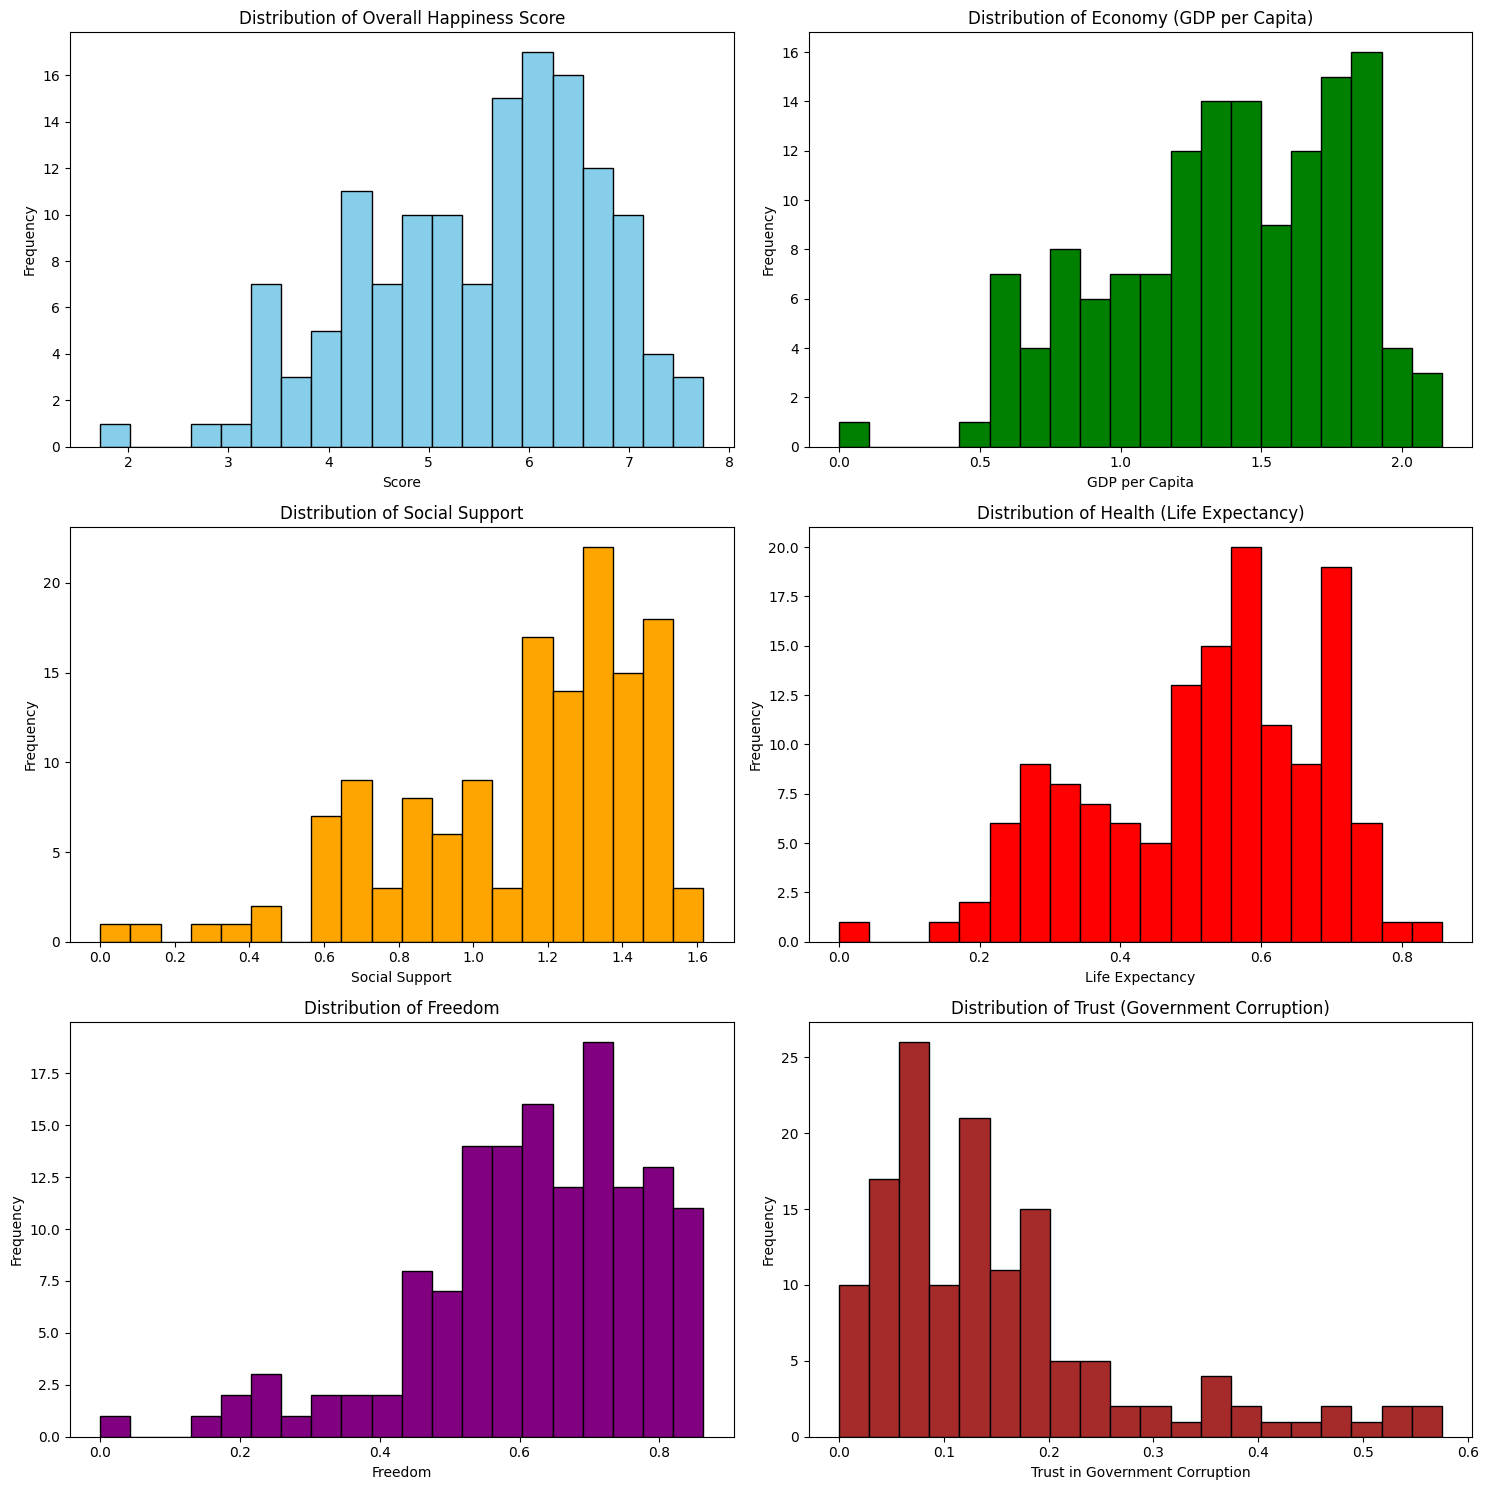

In [164]:
# Setting up subplots for visualizing the distributions of the key metrics
fig, axs = plt.subplots(3, 2, figsize=(15, 15))

# Plot for Score (Overall Happiness)
axs[0, 0].hist(h24_df['Score'], bins=20, color='skyblue', edgecolor='black')
axs[0, 0].set_title('Distribution of Overall Happiness Score')
axs[0, 0].set_xlabel('Score')
axs[0, 0].set_ylabel('Frequency')

# Plot for Economy (GDP per Capita)
axs[0, 1].hist(h24_df['Economy (GDP per Capita)'], bins=20, color='green', edgecolor='black')
axs[0, 1].set_title('Distribution of Economy (GDP per Capita)')
axs[0, 1].set_xlabel('GDP per Capita')
axs[0, 1].set_ylabel('Frequency')

# Plot for Social Support
axs[1, 0].hist(h24_df['Social Support'], bins=20, color='orange', edgecolor='black')
axs[1, 0].set_title('Distribution of Social Support')
axs[1, 0].set_xlabel('Social Support')
axs[1, 0].set_ylabel('Frequency')

# Plot for Health (Life Expectancy)
axs[1, 1].hist(h24_df['Health (Life Expectancy)'], bins=20, color='red', edgecolor='black')
axs[1, 1].set_title('Distribution of Health (Life Expectancy)')
axs[1, 1].set_xlabel('Life Expectancy')
axs[1, 1].set_ylabel('Frequency')

# Plot for Freedom
axs[2, 0].hist(h24_df['Freedom'], bins=20, color='purple', edgecolor='black')
axs[2, 0].set_title('Distribution of Freedom')
axs[2, 0].set_xlabel('Freedom')
axs[2, 0].set_ylabel('Frequency')

# Plot for Trust (Government Corruption)
axs[2, 1].hist(h24_df['Trust (Government Corruption)'], bins=20, color='brown', edgecolor='black')
axs[2, 1].set_title('Distribution of Trust (Government Corruption)')
axs[2, 1].set_xlabel('Trust in Government Corruption')
axs[2, 1].set_ylabel('Frequency')

plt.tight_layout()

# Display the plots
plt.show()


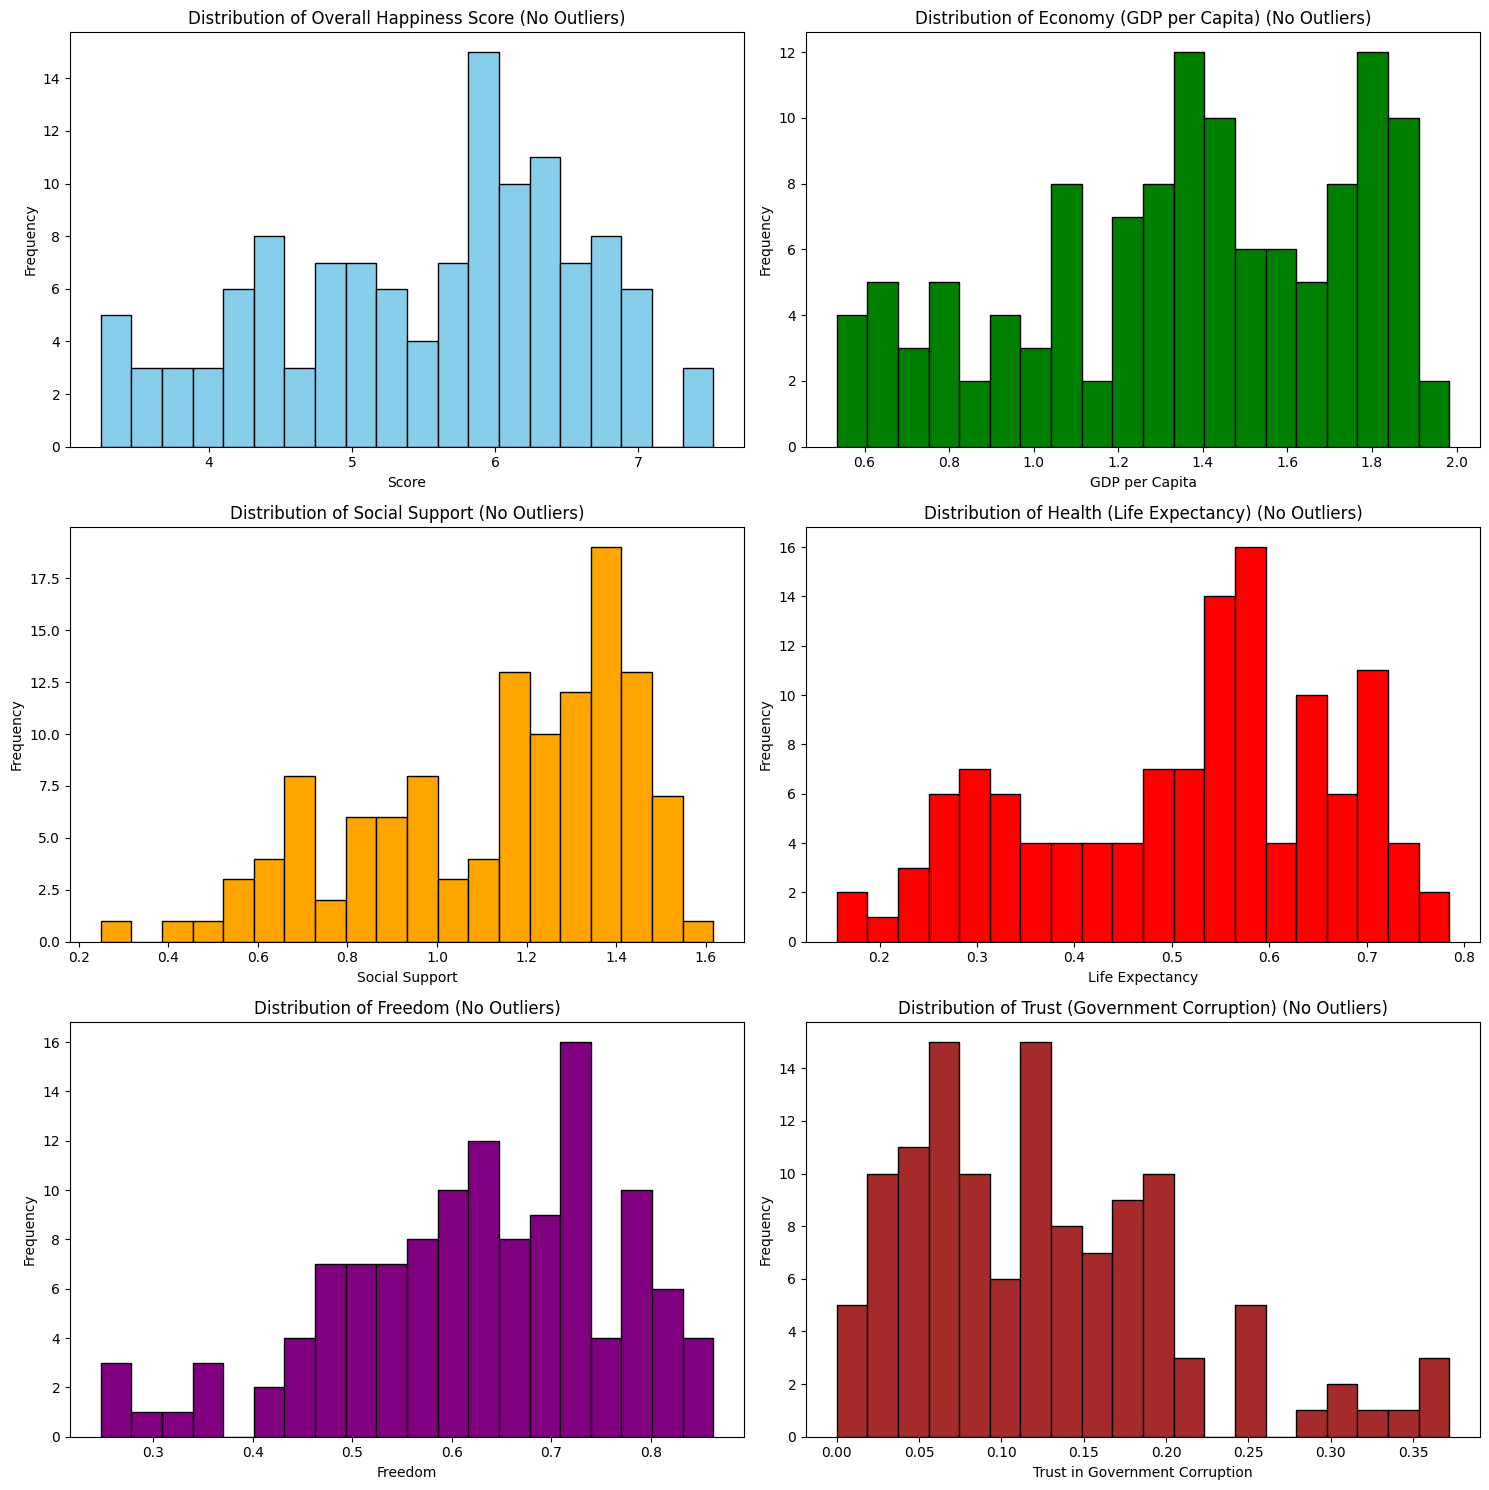

In [83]:
# Using the IQR method to remove outliers for each metric

def remove_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

# Removing outliers from each of the key columns
columns_to_check = ['Score', 'Economy (GDP per Capita)', 'Social Support', 'Health (Life Expectancy)', 
                    'Freedom', 'Trust (Government Corruption)']

h24_df_filtered = h24_df.copy()
for col in columns_to_check:
    h24_df_filtered = remove_outliers(h24_df_filtered, col)

# Plotting the distributions after outlier removal
fig, axs = plt.subplots(3, 2, figsize=(15, 15))

# Plot for Score (Overall Happiness)
axs[0, 0].hist(h24_df_filtered['Score'], bins=20, color='skyblue', edgecolor='black')
axs[0, 0].set_title('Distribution of Overall Happiness Score (No Outliers)')
axs[0, 0].set_xlabel('Score')
axs[0, 0].set_ylabel('Frequency')

# Plot for Economy (GDP per Capita)
axs[0, 1].hist(h24_df_filtered['Economy (GDP per Capita)'], bins=20, color='green', edgecolor='black')
axs[0, 1].set_title('Distribution of Economy (GDP per Capita) (No Outliers)')
axs[0, 1].set_xlabel('GDP per Capita')
axs[0, 1].set_ylabel('Frequency')

# Plot for Social Support
axs[1, 0].hist(h24_df_filtered['Social Support'], bins=20, color='orange', edgecolor='black')
axs[1, 0].set_title('Distribution of Social Support (No Outliers)')
axs[1, 0].set_xlabel('Social Support')
axs[1, 0].set_ylabel('Frequency')

# Plot for Health (Life Expectancy)
axs[1, 1].hist(h24_df_filtered['Health (Life Expectancy)'], bins=20, color='red', edgecolor='black')
axs[1, 1].set_title('Distribution of Health (Life Expectancy) (No Outliers)')
axs[1, 1].set_xlabel('Life Expectancy')
axs[1, 1].set_ylabel('Frequency')

# Plot for Freedom
axs[2, 0].hist(h24_df_filtered['Freedom'], bins=20, color='purple', edgecolor='black')
axs[2, 0].set_title('Distribution of Freedom (No Outliers)')
axs[2, 0].set_xlabel('Freedom')
axs[2, 0].set_ylabel('Frequency')

# Plot for Trust (Government Corruption)
axs[2, 1].hist(h24_df_filtered['Trust (Government Corruption)'], bins=20, color='brown', edgecolor='black')
axs[2, 1].set_title('Distribution of Trust (Government Corruption) (No Outliers)')
axs[2, 1].set_xlabel('Trust in Government Corruption')
axs[2, 1].set_ylabel('Frequency')

plt.tight_layout()

# Display the plots
plt.show()


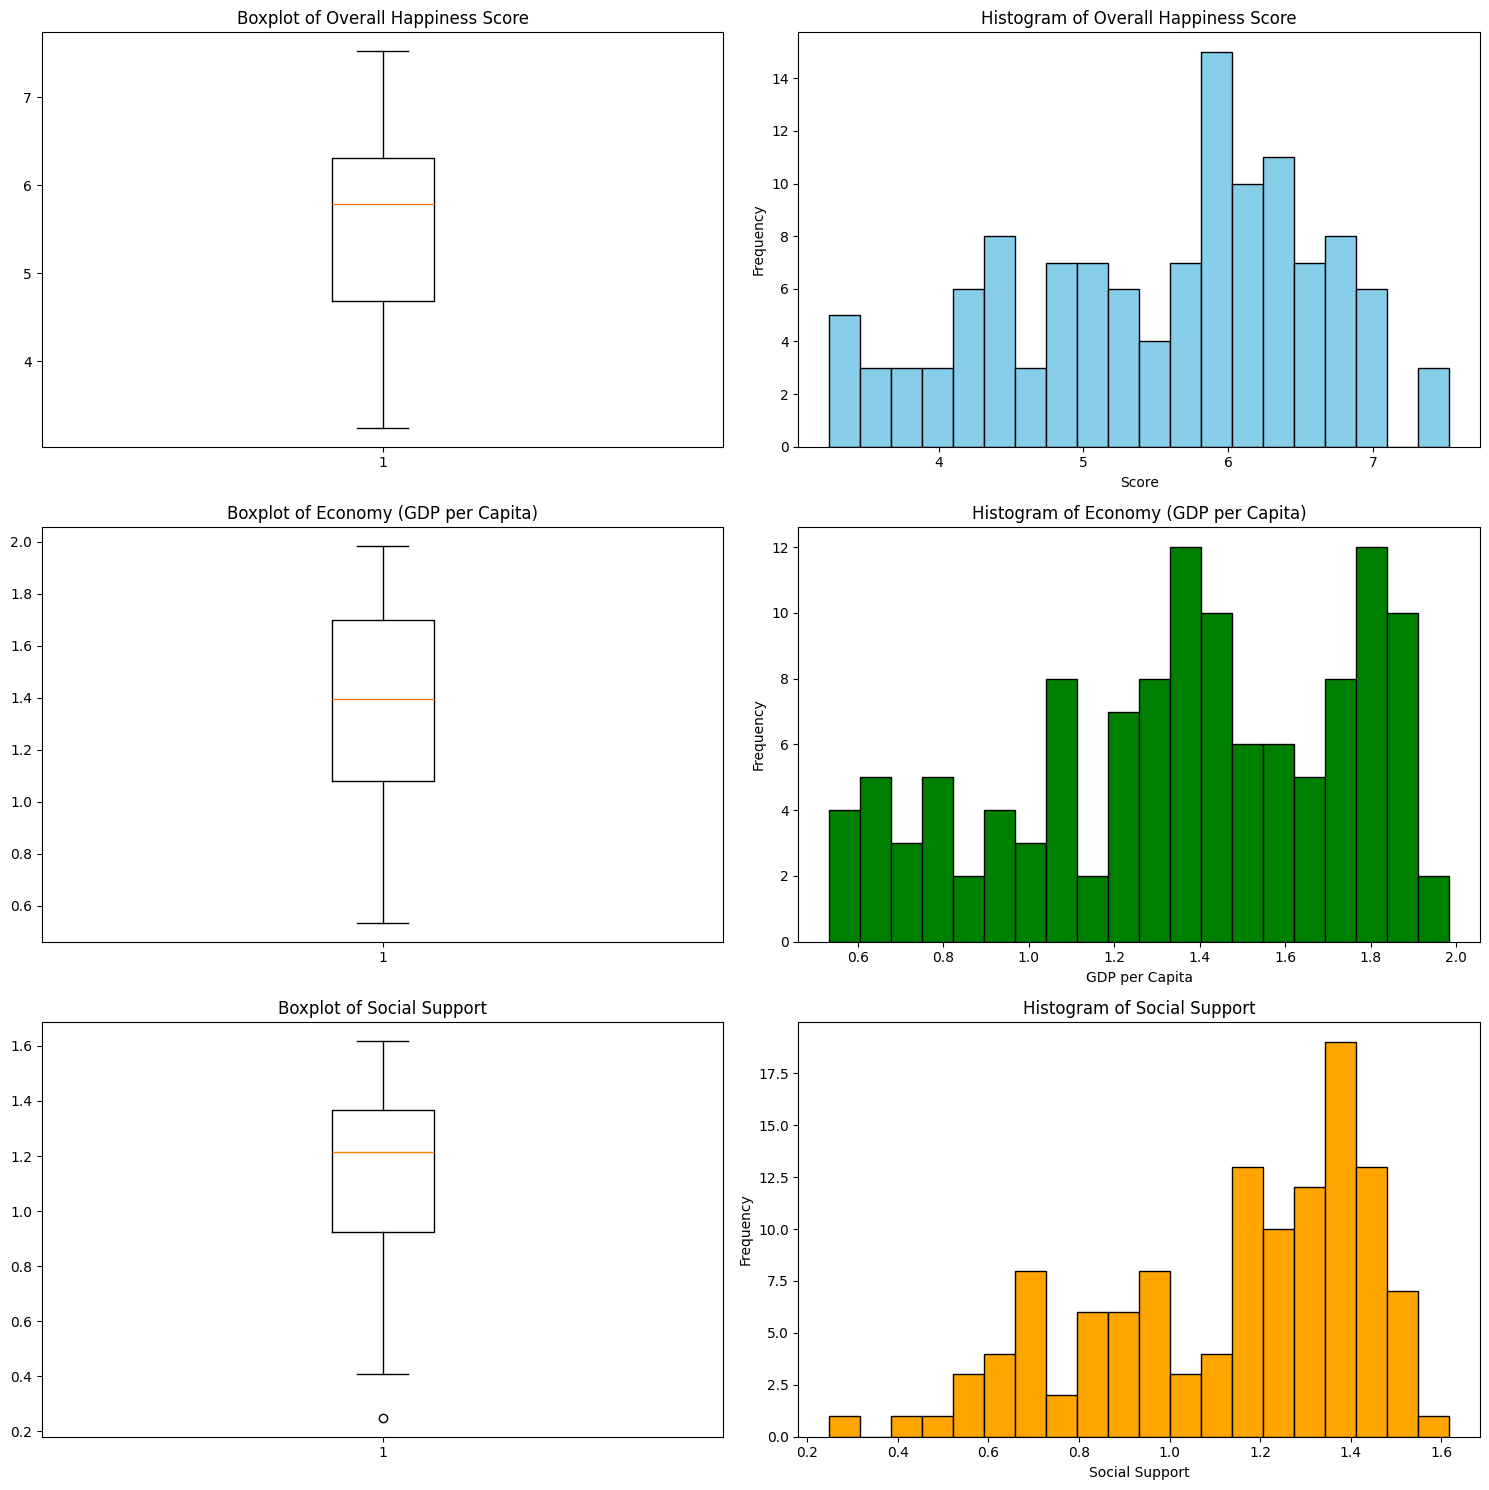

In [84]:
# Creating a boxplot and histogram for each key metric

fig, axs = plt.subplots(3, 2, figsize=(15, 15))

# Boxplot and histogram for Score (Overall Happiness)
axs[0, 0].boxplot(h24_df_filtered['Score'])
axs[0, 0].set_title('Boxplot of Overall Happiness Score')

axs[0, 1].hist(h24_df_filtered['Score'], bins=20, color='skyblue', edgecolor='black')
axs[0, 1].set_title('Histogram of Overall Happiness Score')
axs[0, 1].set_xlabel('Score')
axs[0, 1].set_ylabel('Frequency')

# Boxplot and histogram for Economy (GDP per Capita)
axs[1, 0].boxplot(h24_df_filtered['Economy (GDP per Capita)'])
axs[1, 0].set_title('Boxplot of Economy (GDP per Capita)')

axs[1, 1].hist(h24_df_filtered['Economy (GDP per Capita)'], bins=20, color='green', edgecolor='black')
axs[1, 1].set_title('Histogram of Economy (GDP per Capita)')
axs[1, 1].set_xlabel('GDP per Capita')
axs[1, 1].set_ylabel('Frequency')

# Boxplot and histogram for Social Support
axs[2, 0].boxplot(h24_df_filtered['Social Support'])
axs[2, 0].set_title('Boxplot of Social Support')

axs[2, 1].hist(h24_df_filtered['Social Support'], bins=20, color='orange', edgecolor='black')
axs[2, 1].set_title('Histogram of Social Support')
axs[2, 1].set_xlabel('Social Support')
axs[2, 1].set_ylabel('Frequency')

plt.tight_layout()

# Display the boxplots and histograms
plt.show()


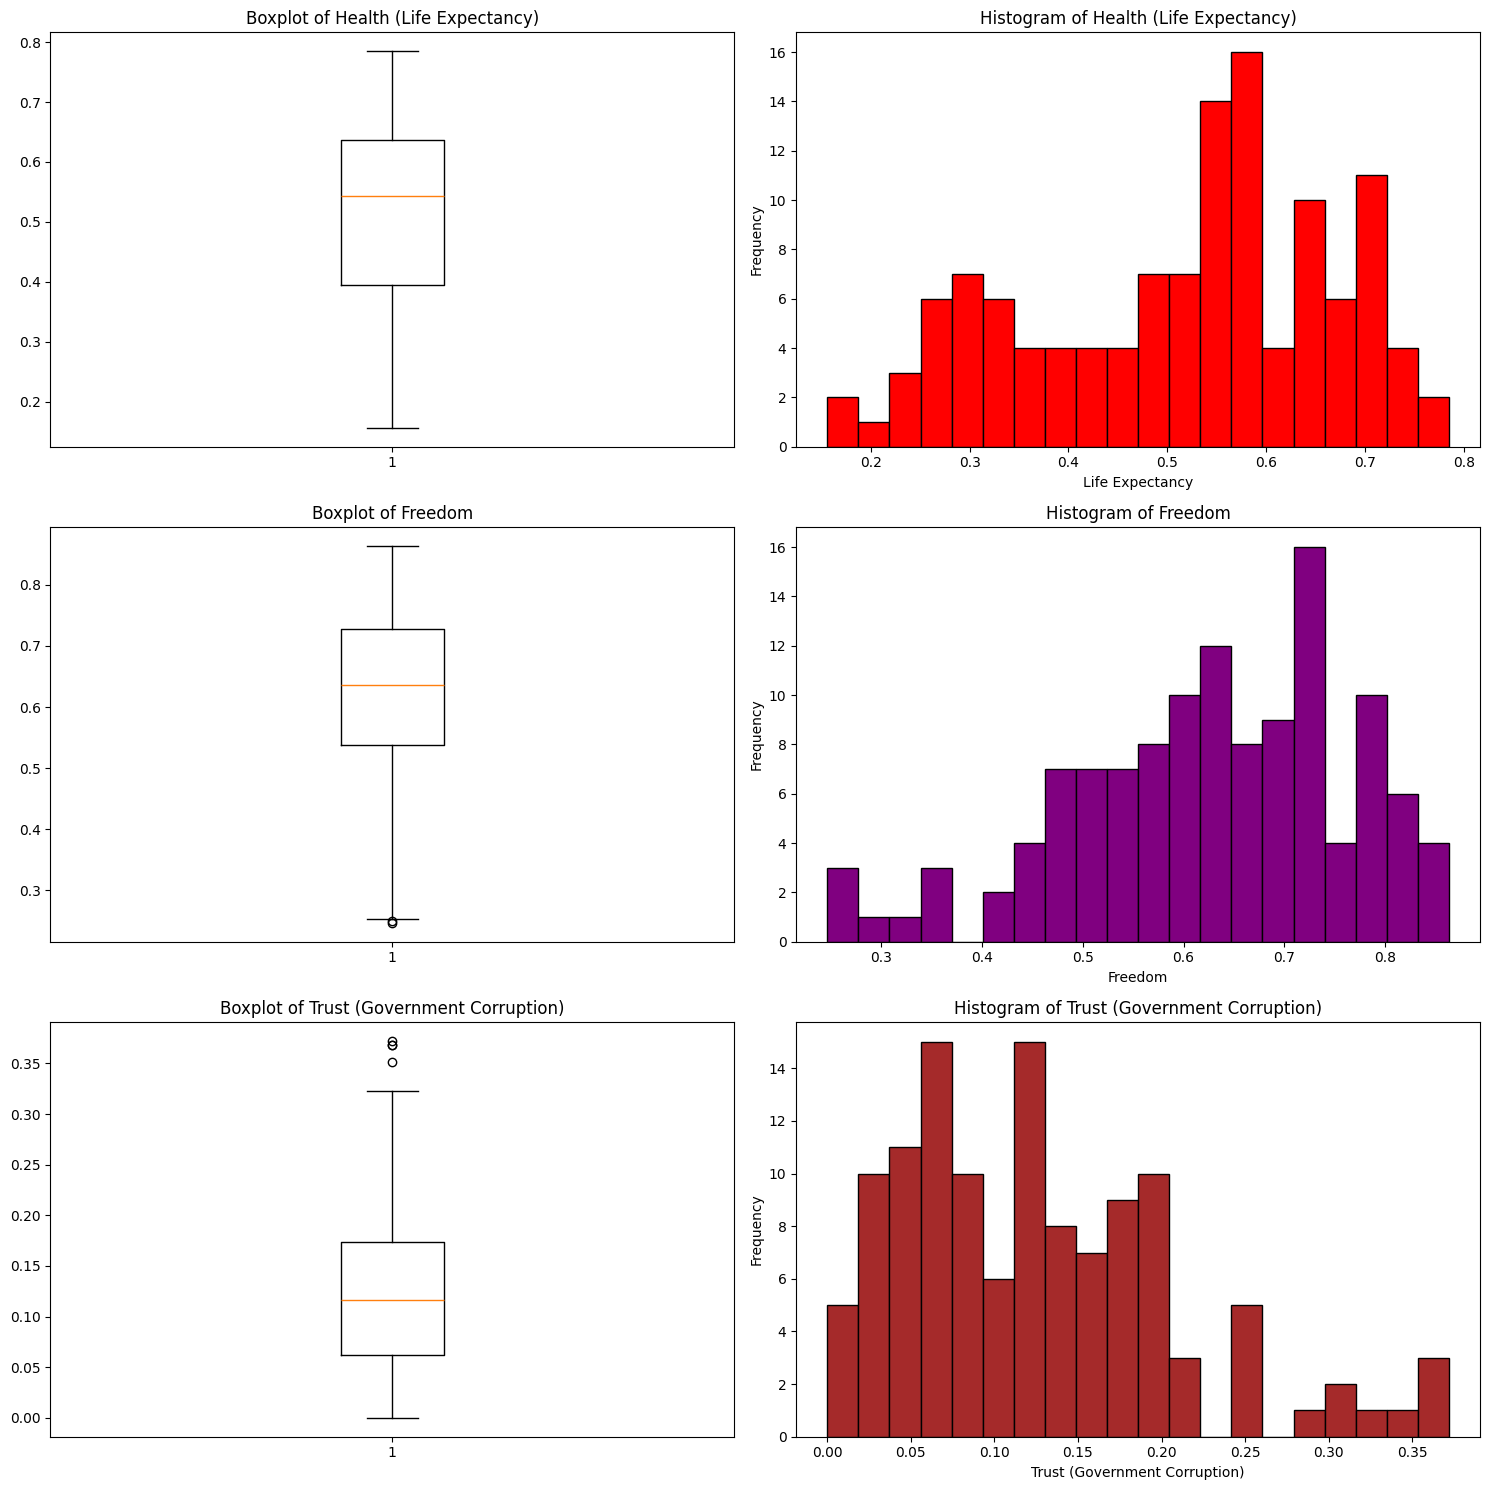

In [85]:
# Creating a boxplot and histogram for Health (Life Expectancy), Freedom, and Trust (Government Corruption)

fig, axs = plt.subplots(3, 2, figsize=(15, 15))

# Boxplot and histogram for Health (Life Expectancy)
axs[0, 0].boxplot(h24_df_filtered['Health (Life Expectancy)'])
axs[0, 0].set_title('Boxplot of Health (Life Expectancy)')

axs[0, 1].hist(h24_df_filtered['Health (Life Expectancy)'], bins=20, color='red', edgecolor='black')
axs[0, 1].set_title('Histogram of Health (Life Expectancy)')
axs[0, 1].set_xlabel('Life Expectancy')
axs[0, 1].set_ylabel('Frequency')

# Boxplot and histogram for Freedom
axs[1, 0].boxplot(h24_df_filtered['Freedom'])
axs[1, 0].set_title('Boxplot of Freedom')

axs[1, 1].hist(h24_df_filtered['Freedom'], bins=20, color='purple', edgecolor='black')
axs[1, 1].set_title('Histogram of Freedom')
axs[1, 1].set_xlabel('Freedom')
axs[1, 1].set_ylabel('Frequency')

# Boxplot and histogram for Trust (Government Corruption)
axs[2, 0].boxplot(h24_df_filtered['Trust (Government Corruption)'])
axs[2, 0].set_title('Boxplot of Trust (Government Corruption)')

axs[2, 1].hist(h24_df_filtered['Trust (Government Corruption)'], bins=20, color='brown', edgecolor='black')
axs[2, 1].set_title('Histogram of Trust (Government Corruption)')
axs[2, 1].set_xlabel('Trust (Government Corruption)')
axs[2, 1].set_ylabel('Frequency')

plt.tight_layout()

# Display the boxplots and histograms
plt.show()


In [148]:
# go to lesson: statistics 1 then statistics 3
# then go to univariate Non graphical analysis
# detect outliers using numerical statistics 

In [169]:
h24_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Rank,140.0,70.500000,40.558600,1.000,35.75000,70.5000,105.25000,140.000
Score,140.0,5.530893,1.181247,1.721,4.63175,5.8005,6.42625,7.741
Upper Whisker,140.0,5.644057,1.165108,1.775,4.76225,5.9110,6.51525,7.815
Lower Whisker,140.0,5.417700,1.198051,1.667,4.50375,5.6765,6.33825,7.667
Economy (GDP per Capita),140.0,1.378807,0.425098,0.000,1.07775,1.4315,1.74150,2.141
Social Support,140.0,1.134329,0.333317,0.000,0.92175,1.2375,1.38325,1.617
Health (Life Expectancy),140.0,0.520886,0.164923,0.000,0.39800,0.5495,0.64850,0.857
Freedom,140.0,0.620621,0.162492,0.000,0.52750,0.6410,0.73600,0.863
Generosity,140.0,0.146271,0.073441,0.000,0.09100,0.1365,0.19250,0.401
Trust (Government Corruption),140.0,0.154121,0.126238,0.000,0.06875,0.1205,0.19375,0.575


In [170]:
h24_df.describe(include='object').T

,count,unique,top,freq
Country,140,140,Finland,1


In [177]:
h24_df['Score'].mean(), h24_df['Score'].median(), h24_df['Score'].mode(), h24_df['Score'].std()

(np.float64(5.530892857142858),
 np.float64(5.8004999999999995),
 0    3.502
 1    5.816
 2    6.188
 Name: Score, dtype: float64,
 np.float64(1.181246864082799))

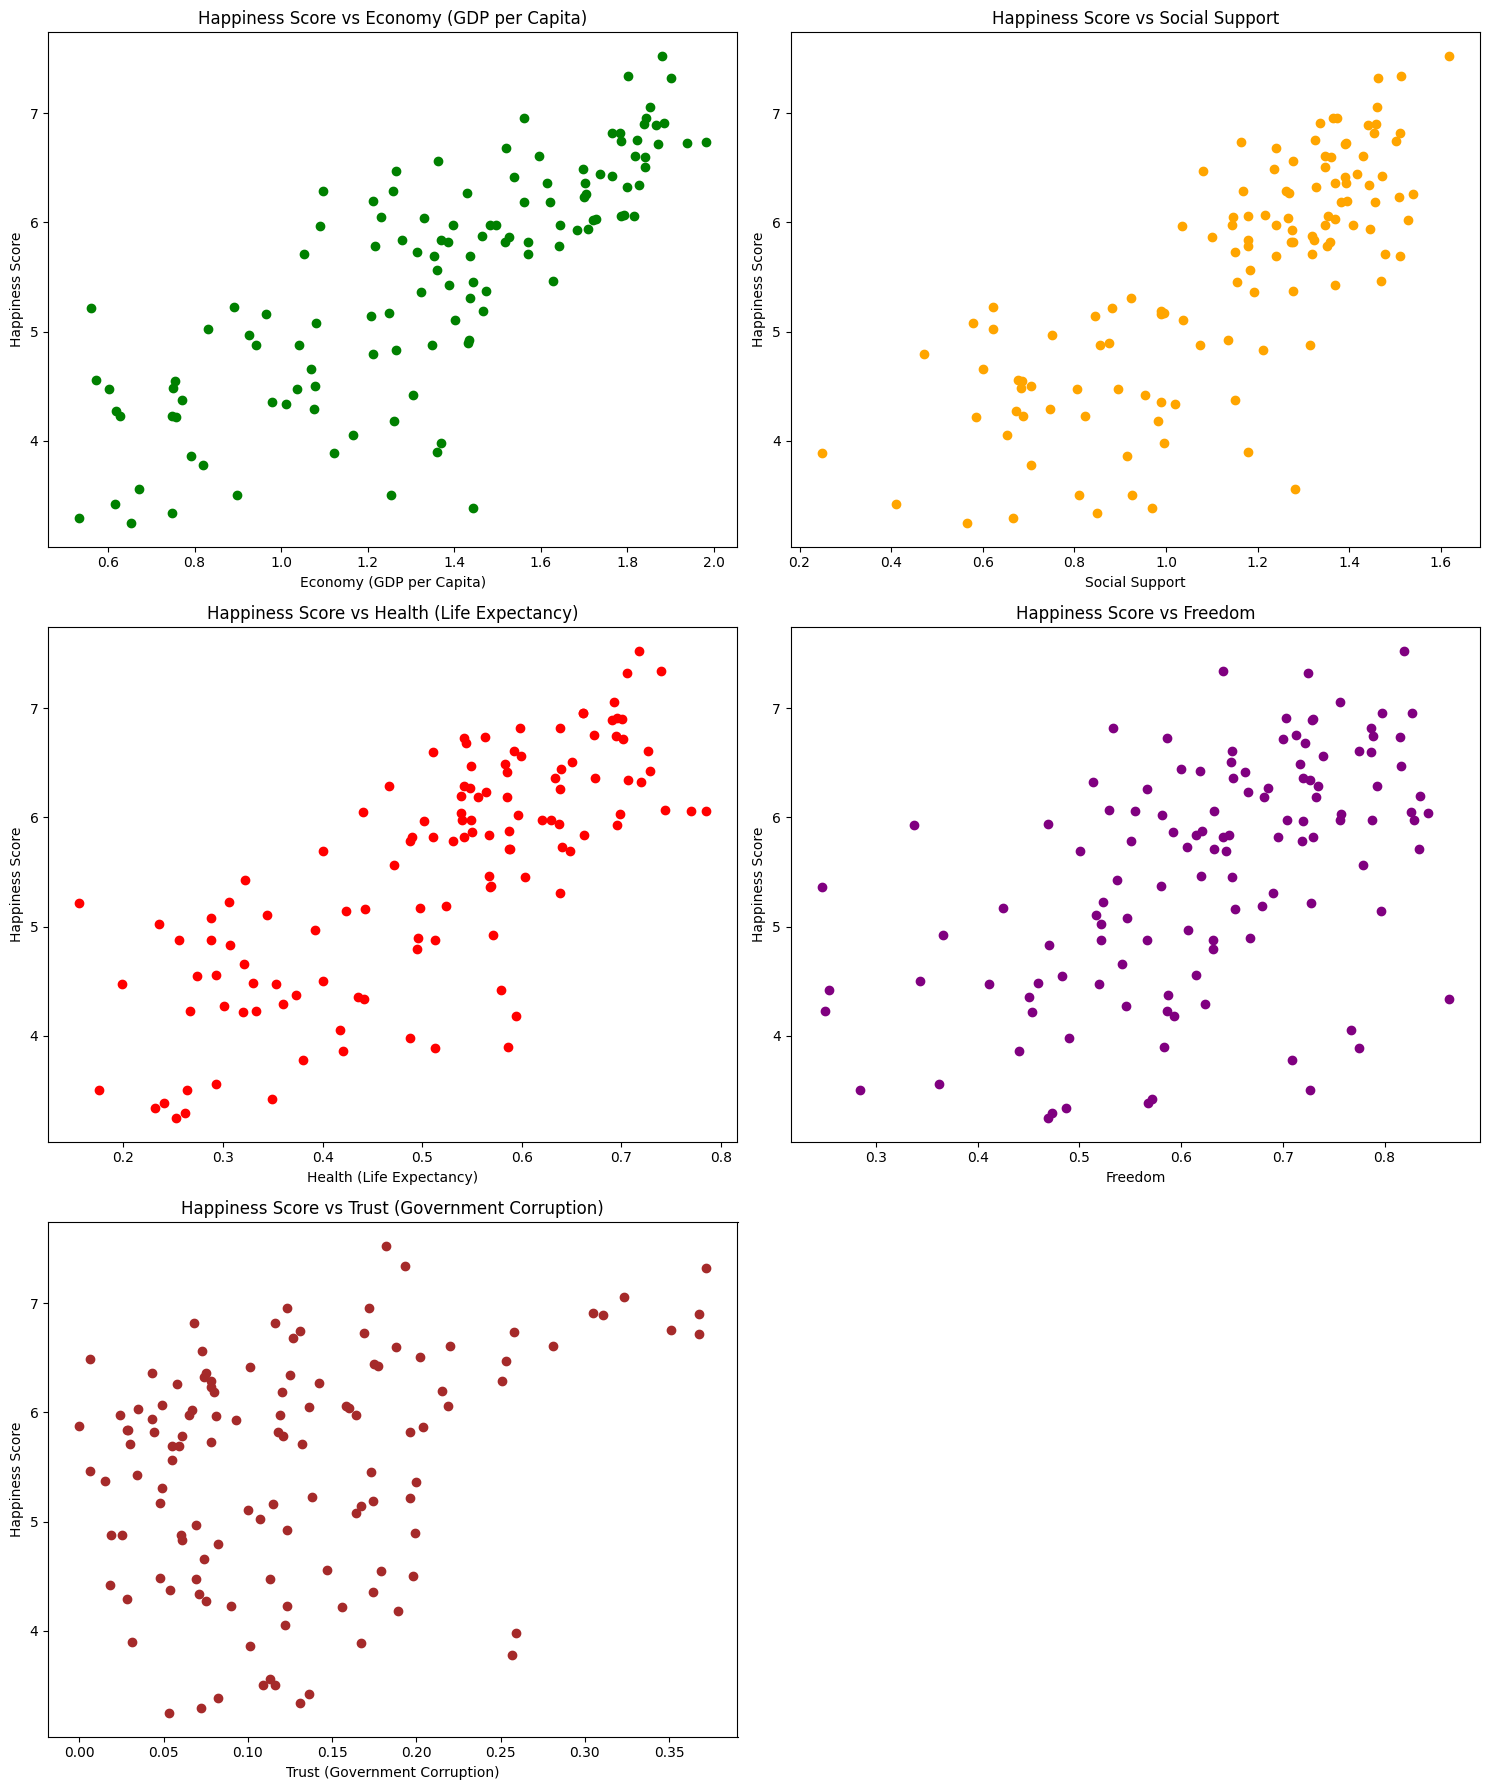

In [181]:
# Creating scatter plots in a 3x2 layout including Trust (Government Corruption)

fig, axs = plt.subplots(3, 2, figsize=(15, 18))

# Scatter plot for Score vs Economy (GDP per Capita)
axs[0, 0].scatter(h24_df_filtered['Economy (GDP per Capita)'], h24_df_filtered['Score'], color='green')
axs[0, 0].set_title('Happiness Score vs Economy (GDP per Capita)')
axs[0, 0].set_xlabel('Economy (GDP per Capita)')
axs[0, 0].set_ylabel('Happiness Score')

# Scatter plot for Score vs Social Support
axs[0, 1].scatter(h24_df_filtered['Social Support'], h24_df_filtered['Score'], color='orange')
axs[0, 1].set_title('Happiness Score vs Social Support')
axs[0, 1].set_xlabel('Social Support')
axs[0, 1].set_ylabel('Happiness Score')

# Scatter plot for Score vs Health (Life Expectancy)
axs[1, 0].scatter(h24_df_filtered['Health (Life Expectancy)'], h24_df_filtered['Score'], color='red')
axs[1, 0].set_title('Happiness Score vs Health (Life Expectancy)')
axs[1, 0].set_xlabel('Health (Life Expectancy)')
axs[1, 0].set_ylabel('Happiness Score')

# Scatter plot for Score vs Freedom
axs[1, 1].scatter(h24_df_filtered['Freedom'], h24_df_filtered['Score'], color='purple')
axs[1, 1].set_title('Happiness Score vs Freedom')
axs[1, 1].set_xlabel('Freedom')
axs[1, 1].set_ylabel('Happiness Score')

# Scatter plot for Score vs Trust (Government Corruption)
axs[2, 0].scatter(h24_df_filtered['Trust (Government Corruption)'], h24_df_filtered['Score'], color='brown')
axs[2, 0].set_title('Happiness Score vs Trust (Government Corruption)')
axs[2, 0].set_xlabel('Trust (Government Corruption)')
axs[2, 0].set_ylabel('Happiness Score')

# Empty subplot for layout symmetry
axs[2, 1].axis('off')

plt.tight_layout()

# Display the scatter plots
plt.show()


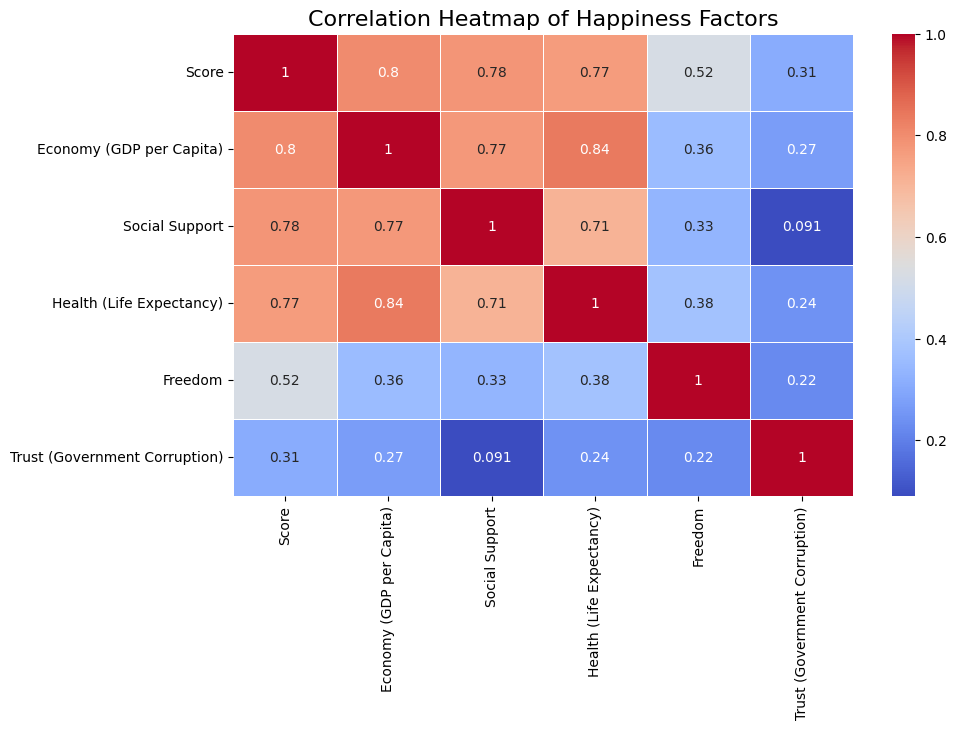

In [184]:
# Calculating the correlation matrix for the relevant columns
correlation_matrix = h24_df_filtered[['Score', 'Economy (GDP per Capita)', 'Social Support', 
                                    'Health (Life Expectancy)', 'Freedom', 'Trust (Government Corruption)']].corr()

# Creating a heatmap for the correlation matrix
plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)

# Adding title for the heatmap
plt.title('Correlation Heatmap of Happiness Factors', fontsize=16)
plt.show()



In [199]:
# Extracting the top 5 countries by each metric for comparison
top_overall = h24_df[['Country', 'Score']].sort_values(by='Score', ascending=False).head(5)
top_economy = h24_df[['Country', 'Economy (GDP per Capita)']].sort_values(by='Economy (GDP per Capita)', ascending=False).head(5)
top_social_support = h24_df[['Country', 'Social Support']].sort_values(by='Social Support', ascending=False).head(5)
top_health = h24_df[['Country', 'Health (Life Expectancy)']].sort_values(by='Health (Life Expectancy)', ascending=False).head(5)
top_freedom = h24_df[['Country', 'Freedom']].sort_values(by='Freedom', ascending=False).head(5)
top_generosity = h24_df[['Country', 'Generosity']].sort_values(by='Generosity', ascending=False).head(5)
top_trust = h24_df[['Country', 'Trust (Government Corruption)']].sort_values(by='Trust (Government Corruption)', ascending=False).head(5)

# Displaying the top countries for each category
top_overall, top_economy, top_social_support, top_health, top_freedom, top_generosity, top_trust


(   Country  Score
 0  Finland  7.741
 1  Denmark  7.583
 2  Iceland  7.525
 3   Sweden  7.344
 4   Israel  7.341,
                  Country  Economy (GDP per Capita)
 7             Luxembourg                     2.141
 16               Ireland                     2.129
 29             Singapore                     2.118
 21  United Arab Emirates                     1.983
 8            Switzerland                     1.970,
         Country  Social Support
 2       Iceland           1.617
 0       Finland           1.572
 44     Slovakia           1.540
 55      Hungary           1.528
 10  New Zealand           1.527,
                       Country  Health (Life Expectancy)
 85  Hong Kong S.A.R. of China                     0.857
 50                      Japan                     0.785
 51                South Korea                     0.770
 29                  Singapore                     0.769
 8                 Switzerland                     0.747,
       Country  Freedom
 118  

# Q1


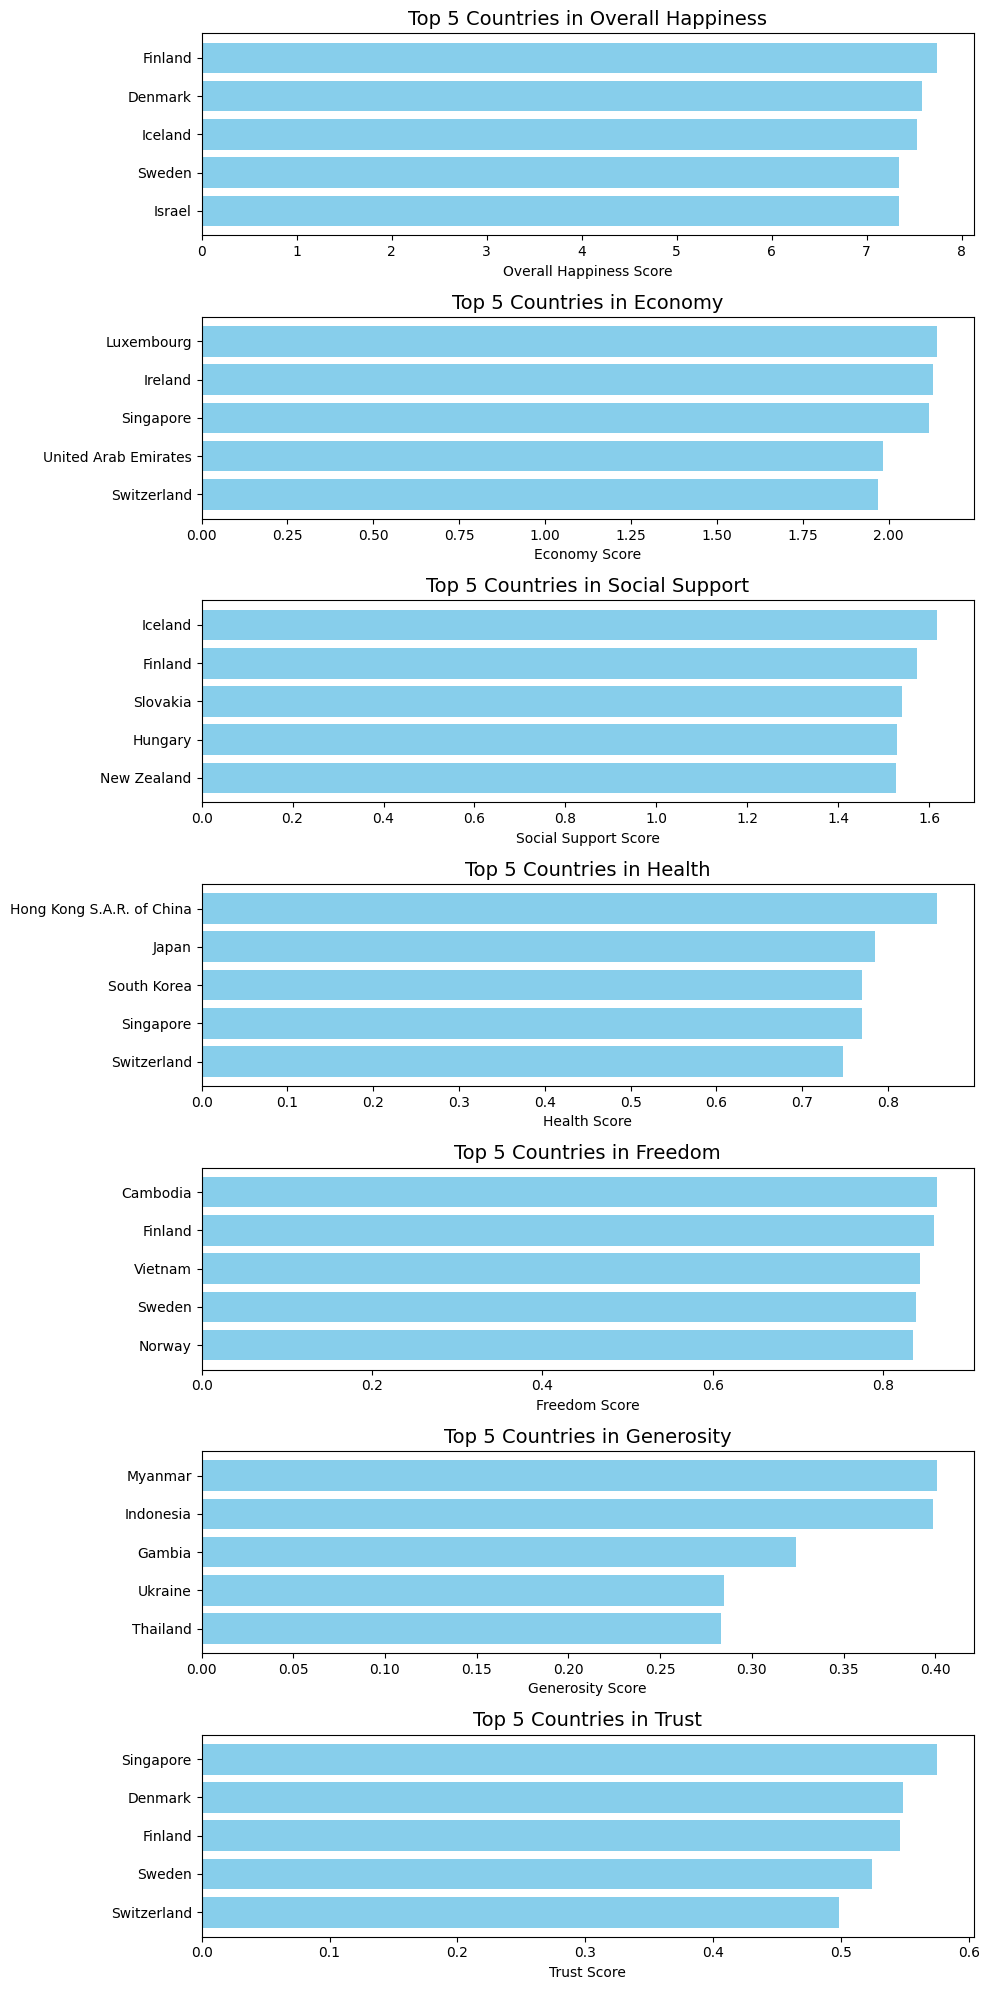

In [200]:
# Q1 What countries or regions rank the highest in overall happiness and each of the six factors contributing to happiness?
# Preparing data for visual representation

# Data for the top 5 countries and their scores for each category
categories = ['Overall Happiness', 'Economy', 'Social Support', 'Health', 'Freedom', 'Generosity', 'Trust']
countries = [
    list(top_overall.iloc[ : , 0].values),  # Overall Happiness 
    list(top_economy.iloc[ : , 0].values),  # Economy 
    list(top_social_support.iloc[ : , 0].values),  # Social Support
    list(top_health.iloc[ : , 0].values),  # Health 
    list(top_freedom.iloc[ : , 0].values),  # Freedom 
    list(top_generosity.iloc[ : , 0].values),  # Generosity 
    list(top_trust.iloc[ : , 0].values)   # Trust 
]

scores = [
    list(top_overall.iloc[ : , 1].values),  # Overall Happiness scores
    list(top_economy.iloc[ : , 1].values),  # Economy scores
    list(top_social_support.iloc[ : , 1].values),  # Social Support scores
    list(top_health.iloc[ : , 1].values),  # Health scores
    list(top_freedom.iloc[ : , 1].values),  # Freedom scores
    list(top_generosity.iloc[ : , 1].values),  # Generosity scores
    list(top_trust.iloc[ : , 1].values)   # Trust scores
]

# Plotting the rankings with the actual scores on the x-axis
fig, axs = plt.subplots(7, 1, figsize=(10, 20))

# Loop through categories and plot the scores
for i, category in enumerate(categories):
    axs[i].barh(countries[i], scores[i], color='skyblue')
    axs[i].invert_yaxis()  # Invert y-axis for better readability
    axs[i].set_title(f'Top 5 Countries in {category}', fontsize=14)
    axs[i].set_xlabel(f'{category} Score')

plt.tight_layout()
plt.show()


# Q2

In [202]:
h15_df.head(2)

,Country,Region,Rank,Score,Standard Error,Economy (GDP per Capita),Family,Health (Life Expectancy),Freedom,Trust (Government Corruption),Generosity,Dystopia Residual
0,Switzerland,Western Europe,1,7.587,0.03411,1.39651,1.34951,0.94143,0.66557,0.41978,0.29678,2.51738
1,Iceland,Western Europe,2,7.561,0.04884,1.30232,1.40223,0.94784,0.62877,0.14145,0.43630,2.70201


In [203]:
h16_df.head(2)

,Country,Region,Rank,Score,Lower Confidence Interval,Upper Confidence Interval,Economy (GDP per Capita),Family,Health (Life Expectancy),Freedom,Trust (Government Corruption),Generosity,Dystopia Residual
0,Denmark,Western Europe,1,7.526,7.460,7.592,1.44178,1.16374,0.79504,0.57941,0.44453,0.36171,2.73939
1,Switzerland,Western Europe,2,7.509,7.428,7.590,1.52733,1.14524,0.86303,0.58557,0.41203,0.28083,2.69463


In [206]:
h17_df.head(2)

,Country,Rank,Score,Whisker High,Whisker Low,Economy (GDP per Capita),Family,Health (Life Expectancy),Freedom,Generosity,Trust (Government Corruption),Dystopia Residual
0,Norway,1,7.537,7.594445,7.479556,1.616463,1.533524,0.796667,0.635423,0.362012,0.315964,2.277027
1,Denmark,2,7.522,7.581728,7.462272,1.482383,1.551122,0.792566,0.626007,0.355280,0.400770,2.313707


In [207]:
# def remove_outliers(df, column):
#     Q1 = df[column].quantile(0.25)
#     Q3 = df[column].quantile(0.75)
#     IQR = Q3 - Q1
#     lower_bound = Q1 - 1.5 * IQR
#     upper_bound = Q3 + 1.5 * IQR
#     return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

# Removing outliers from each of the key columns
columns_to_check = ['Score', 'Economy (GDP per Capita)', 'Family', 'Health (Life Expectancy)', 
                    'Freedom', 'Trust (Government Corruption)', 'Dystopia Residual']

h15_df_filtered = h15_df.copy()
h16_df_filtered = h16_df.copy()
h17_df_filtered = h17_df.copy()

for col in columns_to_check:
    h15_df_filtered = remove_outliers(h15_df_filtered, col)
    h16_df_filtered = remove_outliers(h16_df_filtered, col)
    h17_df_filtered = remove_outliers(h17_df_filtered, col)

In [210]:
h15_df.shape, h16_df.shape, h17_df.shape

((158, 12), (157, 13), (155, 12))

In [209]:
h15_df_filtered.shape, h16_df_filtered.shape, h17_df_filtered.shape

((138, 12), (139, 13), (134, 12))

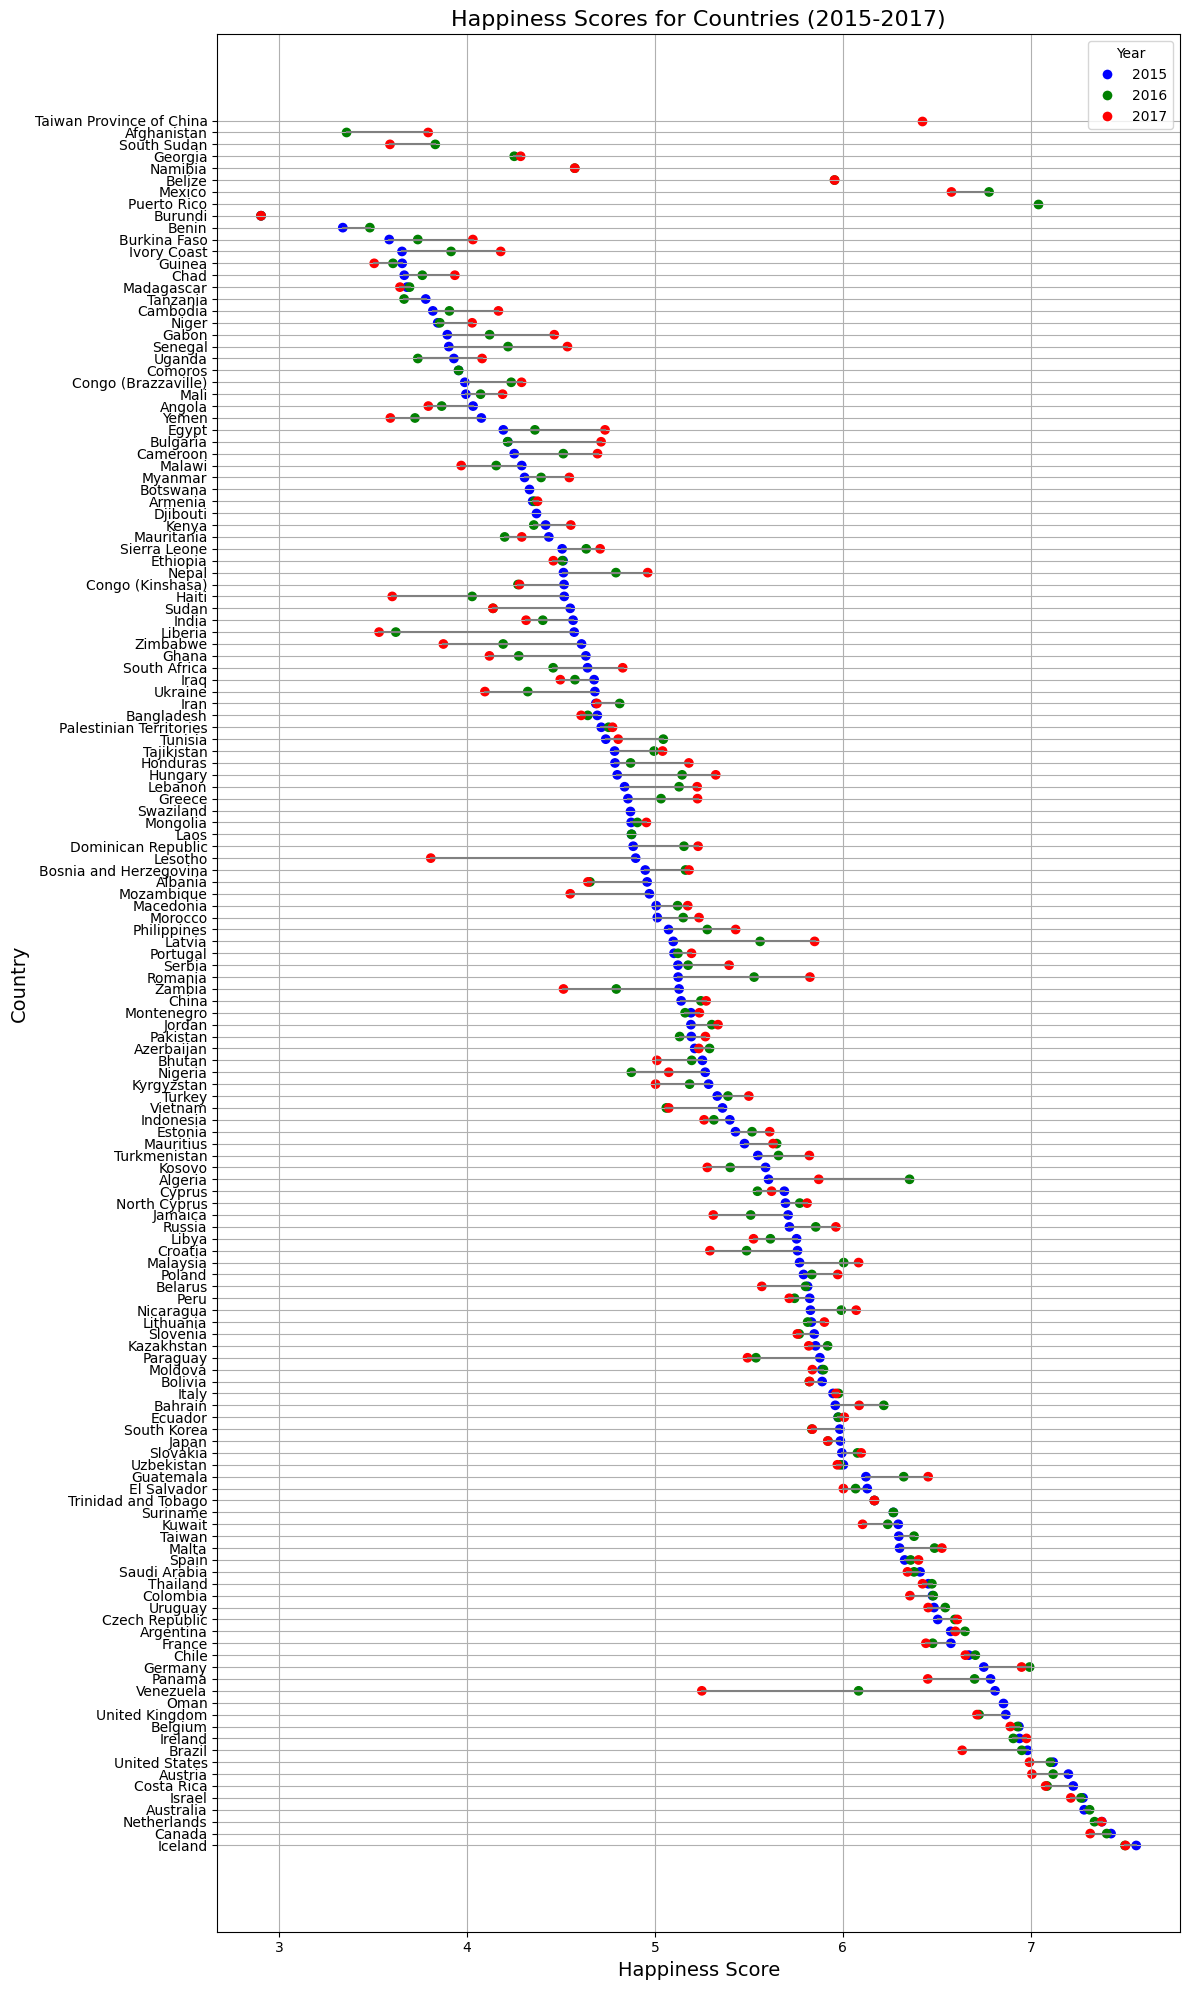

In [212]:
# Add the Year column for each dataset
h15_df_filtered['Year'] = 2015
h16_df_filtered['Year'] = 2016
h17_df_filtered['Year'] = 2017

# Keep only the common columns for all three datasets
common_columns = ['Country', 'Year', 'Score']
combined_data = pd.concat([h15_df_filtered[common_columns], h16_df_filtered[common_columns], h17_df_filtered[common_columns]])

# Set up the plot
plt.figure(figsize=(12, 20))

# Define colors for each year
colors = {2015: 'blue', 2016: 'green', 2017: 'red'}

# Get unique countries
countries = combined_data['Country'].unique()

# Plot each country's scores with different colors for each year
for country in countries:
    country_data = combined_data[combined_data['Country'] == country].sort_values('Year')
    scores = country_data['Score'].values
    years = country_data['Year'].values
    
    # Plot each year with a distinct color and connect the points
    plt.scatter(scores, [country] * len(scores), c=[colors[year] for year in years])
    plt.plot(scores, [country] * len(scores), linestyle='-', color='gray')  # Connect the scores

# Add a legend to explain the colors for each year
legend_labels = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markersize=8, label=f"{year}")
                 for year, color in colors.items()]
plt.legend(handles=legend_labels, title="Year", loc='upper right')

# Set title and axis labels
plt.title("Happiness Scores for Countries (2015-2017)", fontsize=16)
plt.xlabel("Happiness Score", fontsize=14)
plt.ylabel("Country", fontsize=14)
plt.grid(True)

# Increase the font size of y-axis labels (country names)
plt.yticks(fontsize=10)

# Show the plot
plt.tight_layout()
plt.show()

# Q3

<Figure size 1000x600 with 0 Axes>

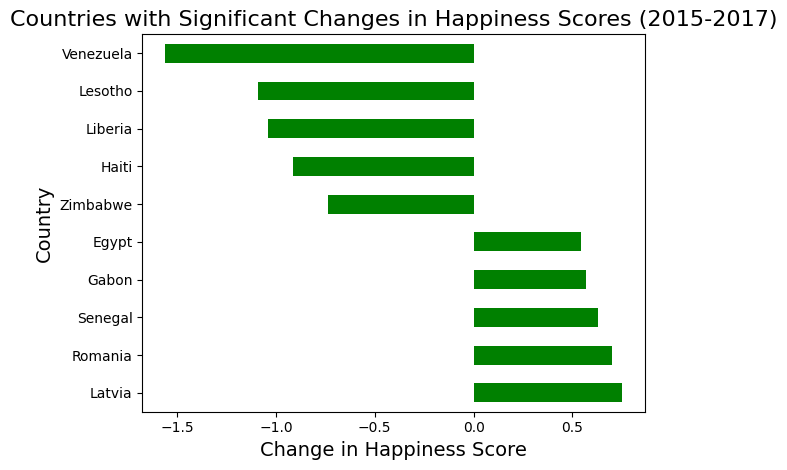

In [213]:
# Pivot the data to make it easier to calculate changes
pivoted_data = combined_data.pivot(index='Country', columns='Year', values='Score')

# Calculate the change in score between 2015 and 2017
pivoted_data['Change_2015_2017'] = pivoted_data[2017] - pivoted_data[2015]

# Drop rows with NaN values in the relevant columns
filtered_data = pivoted_data.dropna(subset=['Change_2015_2017'])

# Sort the data again to check for largest increases and decreases
sorted_filtered_data = filtered_data[['Change_2015_2017']].sort_values(by='Change_2015_2017', ascending=False)

# Get the top 5 increases and top 5 decreases
top_increases_filtered = sorted_filtered_data.head(5)
top_decreases_filtered = sorted_filtered_data.tail(5)

# Combine the data for plotting (top increases and top decreases)
significant_changes = pd.concat([top_increases_filtered, top_decreases_filtered])

# Plotting the countries with the most significant changes
plt.figure(figsize=(10, 6))
significant_changes.plot(kind='barh', color=['green' if x > 0 else 'red' for x in significant_changes['Change_2015_2017']], legend=False)

# Adding labels and title
plt.title("Countries with Significant Changes in Happiness Scores (2015-2017)", fontsize=16)
plt.xlabel("Change in Happiness Score", fontsize=14)
plt.ylabel("Country", fontsize=14)

# Display the plot
plt.tight_layout()
plt.show()